  IC3392: HII=14884, SF=19776 pixels
  IC3392: HII=14884, SF=19776 pixels
  NGC4064: HII=6820, SF=15383 pixels
  NGC4064: HII=6820, SF=15383 pixels
  NGC4192: HII=145934, SF=275015 pixels
  NGC4192: HII=145934, SF=275015 pixels
  NGC4293: HII=3854, SF=8590 pixels
  NGC4293: HII=3854, SF=8590 pixels
  NGC4298: HII=156350, SF=181696 pixels
  NGC4298: HII=156350, SF=181696 pixels
  NGC4330: HII=42566, SF=43709 pixels
  NGC4330: HII=42566, SF=43709 pixels
  NGC4396: HII=81728, SF=81734 pixels
  NGC4396: HII=81728, SF=81734 pixels
  NGC4419: HII=6886, SF=22002 pixels
  NGC4419: HII=6886, SF=22002 pixels
  NGC4457: HII=6000, SF=24136 pixels
  NGC4457: HII=6000, SF=24136 pixels
  NGC4501: HII=260854, SF=419043 pixels
  NGC4501: HII=260854, SF=419043 pixels
  NGC4522: HII=39354, SF=40444 pixels
  NGC4694: HII=2585, SF=3851 pixels
  NGC4522: HII=39354, SF=40444 pixels
  NGC4694: HII=2585, SF=3851 pixels
  NGC4698: HII=10042, SF=34421 pixels
  NGC4698: HII=10042, SF=34421 pixels

Total combined 

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_87520/942972346.py:338: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


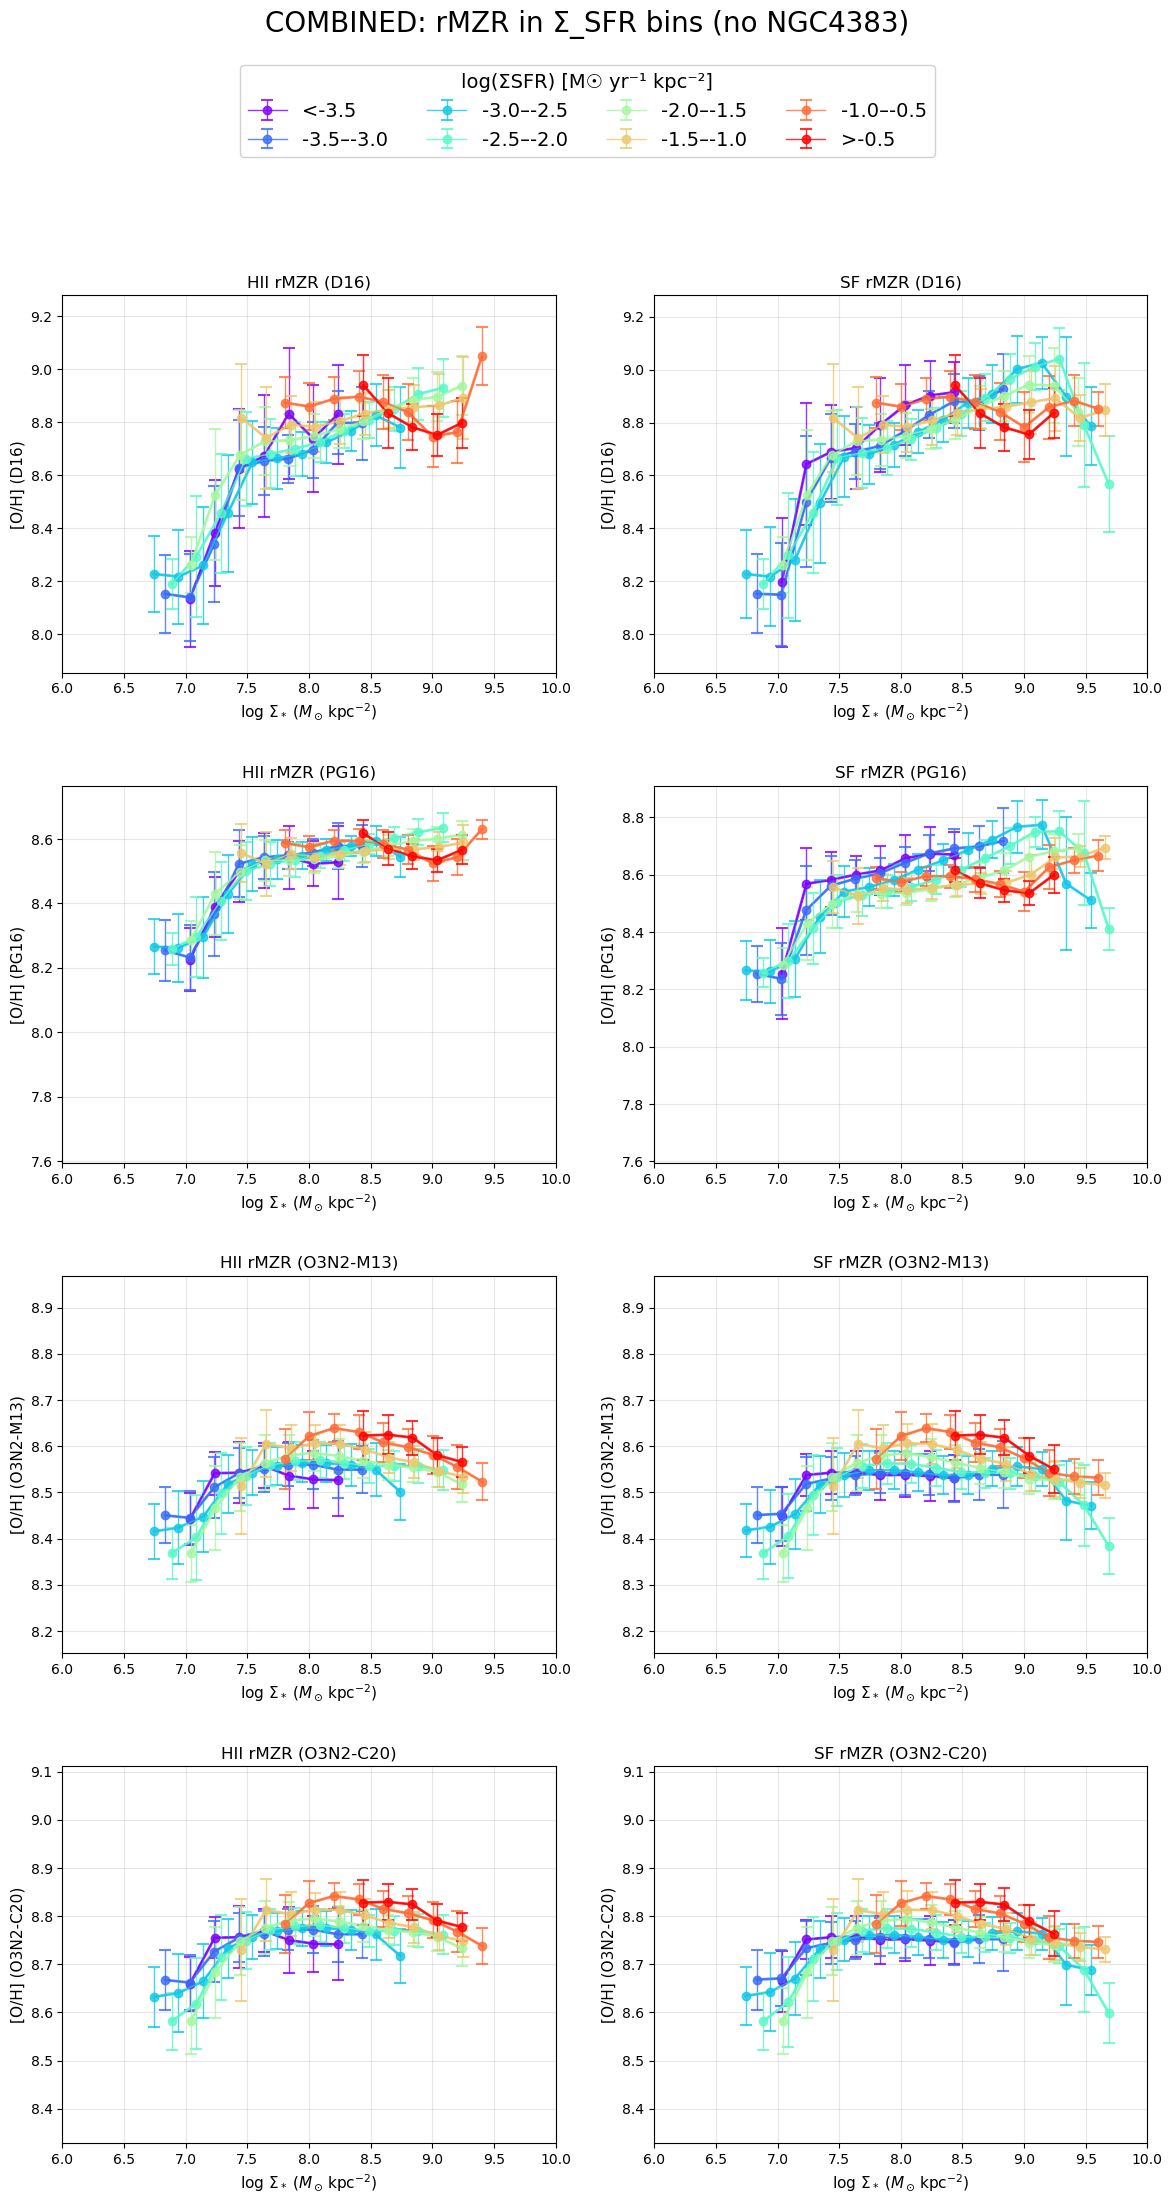


=== MASTER COMBINED FIGURE SUMMARY ===
Successfully created combined figure from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698


In [2]:
# ------------------------------------------------------------------
# MASTER COMBINED FIGURE: rMZR plots
# Layout: GridSpec with 4 rows x 2 columns
# Rows 0-3: rMZR for 4 calibrations
# Column 0: HII
# Column 1: SF
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import matplotlib.gridspec as gridspec

# BPT reference line functions (keeping these if needed for future or just in case, though not used for plotting anymore)
def kewley01_N2(x):
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):
    return 0.61/(x-0.05) + 1.30

def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30

def kewley06_Sy_LIN(x):
    return 1.89*x + 0.76

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for both HII and SF regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
        # Emission lines
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
            HB4861_FLUX_corr, HA6562_FLUX_corr, OIII5006_FLUX_corr, 
            NII6583_FLUX_corr, SII6716_FLUX_corr, SII6730_FLUX_corr)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins if f.name.split('_')[0] != 'NGC4383']

# Collect all spaxels - MZR data
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

all_logSigmaM_SF = []
all_logSigmaSFR_SF = []
all_oh_d16_SF = []
all_oh_pg16_SF = []
all_oh_o3n2_m13_SF = []
all_oh_o3n2_c20_SF = []

# Collect all spaxels - BPT data
all_logN2_hii = []
all_logO3_hii = []
all_logS2_hii = []
all_logSFR_hii = []

all_logN2_sf = []
all_logO3_sf = []
all_logS2_sf = []
all_logSFR_sf = []

print("Collecting data from all galaxies...")
for gal in galaxies:
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        # Load all data
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
         logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
         HB, HA, OIII, NII, SII6716, SII6730) = load_maps_all_calibrations(gal)

        # Common mask for HII
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                           np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII) &
                           np.isfinite(HB) & np.isfinite(HA) & np.isfinite(OIII) & 
                           np.isfinite(NII) & np.isfinite(SII6716) & np.isfinite(SII6730))
        
        # Common mask for SF
        common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                          np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                          np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF) &
                          np.isfinite(HB) & np.isfinite(HA) & np.isfinite(OIII) & 
                          np.isfinite(NII) & np.isfinite(SII6716) & np.isfinite(SII6730))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)}, SF={np.sum(common_mask_SF)} pixels")
        
        # Append MZR data - HII
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
        
        # Append MZR data - SF
        all_logSigmaM_SF.extend(logSigmaM[common_mask_SF].flatten())
        all_logSigmaSFR_SF.extend(logSigmaSFR_SF[common_mask_SF].flatten())
        all_oh_d16_SF.extend(oh_d16_SF[common_mask_SF].flatten())
        all_oh_pg16_SF.extend(oh_pg16_SF[common_mask_SF].flatten())
        all_oh_o3n2_m13_SF.extend(oh_o3n2_m13_SF[common_mask_SF].flatten())
        all_oh_o3n2_c20_SF.extend(oh_o3n2_c20_SF[common_mask_SF].flatten())
        
        # Calculate BPT ratios - HII
        logN2_hii = np.log10(NII[common_mask_HII] / HA[common_mask_HII])
        logO3_hii = np.log10(OIII[common_mask_HII] / HB[common_mask_HII])
        logS2_hii = np.log10((SII6716[common_mask_HII] + SII6730[common_mask_HII]) / HA[common_mask_HII])
        
        all_logN2_hii.extend(logN2_hii.flatten())
        all_logO3_hii.extend(logO3_hii.flatten())
        all_logS2_hii.extend(logS2_hii.flatten())
        all_logSFR_hii.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        
        # Calculate BPT ratios - SF
        logN2_sf = np.log10(NII[common_mask_SF] / HA[common_mask_SF])
        logO3_sf = np.log10(OIII[common_mask_SF] / HB[common_mask_SF])
        logS2_sf = np.log10((SII6716[common_mask_SF] + SII6730[common_mask_SF]) / HA[common_mask_SF])
        
        all_logN2_sf.extend(logN2_sf.flatten())
        all_logO3_sf.extend(logO3_sf.flatten())
        all_logS2_sf.extend(logS2_sf.flatten())
        all_logSFR_sf.extend(logSigmaSFR_SF[common_mask_SF].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays - MZR
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)

all_logSigmaM_SF = np.array(all_logSigmaM_SF)
all_logSigmaSFR_SF = np.array(all_logSigmaSFR_SF)
all_oh_d16_SF = np.array(all_oh_d16_SF)
all_oh_pg16_SF = np.array(all_oh_pg16_SF)
all_oh_o3n2_m13_SF = np.array(all_oh_o3n2_m13_SF)
all_oh_o3n2_c20_SF = np.array(all_oh_o3n2_c20_SF)

# Convert to numpy arrays - BPT
all_logN2_hii = np.array(all_logN2_hii)
all_logO3_hii = np.array(all_logO3_hii)
all_logS2_hii = np.array(all_logS2_hii)
all_logSFR_hii = np.array(all_logSFR_hii)

all_logN2_sf = np.array(all_logN2_sf)
all_logO3_sf = np.array(all_logO3_sf)
all_logS2_sf = np.array(all_logS2_sf)
all_logSFR_sf = np.array(all_logSFR_sf)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")
print(f"Total combined pixels (SF): {len(all_logSigmaM_SF)}")

# Define Σ_SFR bins - 8 bins matching cell 10's left panel
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
n_bins = len(sfr_bin_edges) - 1
colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
]

# Assign SFR bin indices
sfr_bin_indices_hii = np.digitize(all_logSFR_hii, sfr_bin_edges) - 1
sfr_bin_indices_hii = np.clip(sfr_bin_indices_hii, 0, n_bins - 1)

sfr_bin_indices_sf = np.digitize(all_logSFR_sf, sfr_bin_edges) - 1
sfr_bin_indices_sf = np.clip(sfr_bin_indices_sf, 0, n_bins - 1)

# Create figure with GridSpec: 4 rows x 2 columns
fig = plt.figure(figsize=(14, 24))
gs = gridspec.GridSpec(4, 2, figure=fig, wspace=0.2, hspace=0.3)

# Calibrations for rMZR
calibrations_HII = [
    (all_oh_d16_HII, 'D16'),
    (all_oh_pg16_HII, 'PG16'),
    (all_oh_o3n2_m13_HII, 'O3N2-M13'),
    (all_oh_o3n2_c20_HII, 'O3N2-C20')
]

calibrations_SF = [
    (all_oh_d16_SF, 'D16'),
    (all_oh_pg16_SF, 'PG16'),
    (all_oh_o3n2_m13_SF, 'O3N2-M13'),
    (all_oh_o3n2_c20_SF, 'O3N2-C20')
]

legend_handles = []
legend_labels = []

# ==== Rows 0-3: rMZR for 4 calibrations ====
for row_idx, ((oh_data_HII, calib_name_HII), (oh_data_SF, calib_name_SF)) in enumerate(zip(calibrations_HII, calibrations_SF)):
    print(f"\nProcessing {calib_name_HII} calibration:")
    
    # Axes for this row (HII left, SF right)
    ax_HII = fig.add_subplot(gs[row_idx, 0])
    ax_SF = fig.add_subplot(gs[row_idx, 1])
    
    # Calculate y-axis ranges
    all_y_HII = []
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
        if np.sum(in_bin) >= 10:
            all_y_HII.extend(oh_data_HII[in_bin])
    ylim_HII = (np.min(all_y_HII) - 0.05, np.max(all_y_HII) + 0.05) if all_y_HII else (8.0, 9.3)
    
    all_y_SF = []
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_SF >= sfr_bin_edges[i]) & (all_logSigmaSFR_SF < sfr_bin_edges[i+1])
        if np.sum(in_bin) >= 10:
            all_y_SF.extend(oh_data_SF[in_bin])
    ylim_SF = (np.min(all_y_SF) - 0.05, np.max(all_y_SF) + 0.05) if all_y_SF else (8.0, 9.3)
    
    # Plot each SFR bin for HII (left column)
    for i in range(n_bins):
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
        if np.sum(in_bin_HII) >= 10:
            # Plot median with error bars
            mass_centers, medians, stds, counts, valid_idx = calculate_binned_stats(
                all_logSigmaM_HII[in_bin_HII], oh_data_HII[in_bin_HII])
            if len(mass_centers) > 0:
                err = ax_HII.errorbar(mass_centers, medians, yerr=stds, color=colors[i], 
                               marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                
                # Collect handles for legend from the first plot (e.g. D16 HII)
                if row_idx == 0 and len(legend_handles) < n_bins:
                     legend_handles.append(err)
                     legend_labels.append(bin_labels[i])

                # Connect consecutive bins
                for j in range(len(valid_idx) - 1):
                    if valid_idx[j + 1] - valid_idx[j] == 1:
                        ax_HII.plot([mass_centers[j], mass_centers[j + 1]], 
                                   [medians[j], medians[j + 1]], color=colors[i], linewidth=2, alpha=0.8)
    
    # Plot each SFR bin for SF (right column)
    for i in range(n_bins):
        in_bin_SF = (all_logSigmaSFR_SF >= sfr_bin_edges[i]) & (all_logSigmaSFR_SF < sfr_bin_edges[i+1])
        if np.sum(in_bin_SF) >= 10:
            # Plot median with error bars
            mass_centers, medians, stds, counts, valid_idx = calculate_binned_stats(
                all_logSigmaM_SF[in_bin_SF], oh_data_SF[in_bin_SF])
            if len(mass_centers) > 0:
                ax_SF.errorbar(mass_centers, medians, yerr=stds, color=colors[i], 
                              marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                # Connect consecutive bins
                for j in range(len(valid_idx) - 1):
                    if valid_idx[j + 1] - valid_idx[j] == 1:
                        ax_SF.plot([mass_centers[j], mass_centers[j + 1]], 
                                  [medians[j], medians[j + 1]], color=colors[i], linewidth=2, alpha=0.8)
    
    # Format HII axis
    ax_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
    ax_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=11)
    ax_HII.set_xlim(6, 10)
    ax_HII.set_ylim(ylim_HII)
    ax_HII.set_title(f'HII rMZR ({calib_name_HII})', fontsize=12)
    ax_HII.grid(True, alpha=0.3)
    
    # Format SF axis
    ax_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
    ax_SF.set_ylabel(f'[O/H] ({calib_name_SF})', fontsize=11)
    ax_SF.set_xlim(6, 10)
    ax_SF.set_ylim(ylim_SF)
    ax_SF.set_title(f'SF rMZR ({calib_name_SF})', fontsize=12)
    ax_SF.grid(True, alpha=0.3)

# Add shared legend
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
          ncol=min(len(legend_labels), 4), fontsize=14, framealpha=0.9, 
          title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=14, markerscale=1)

fig.suptitle(f'COMBINED: rMZR in Σ_SFR bins (no NGC4383)', fontsize=20, y=0.999)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"\n=== MASTER COMBINED FIGURE SUMMARY ===")
print(f"Successfully created combined figure from {len(galaxies)} galaxies")
print(f"Galaxies included: {', '.join(galaxies)}")

Processing galaxies...
Computing global trends...
Computing global trends...


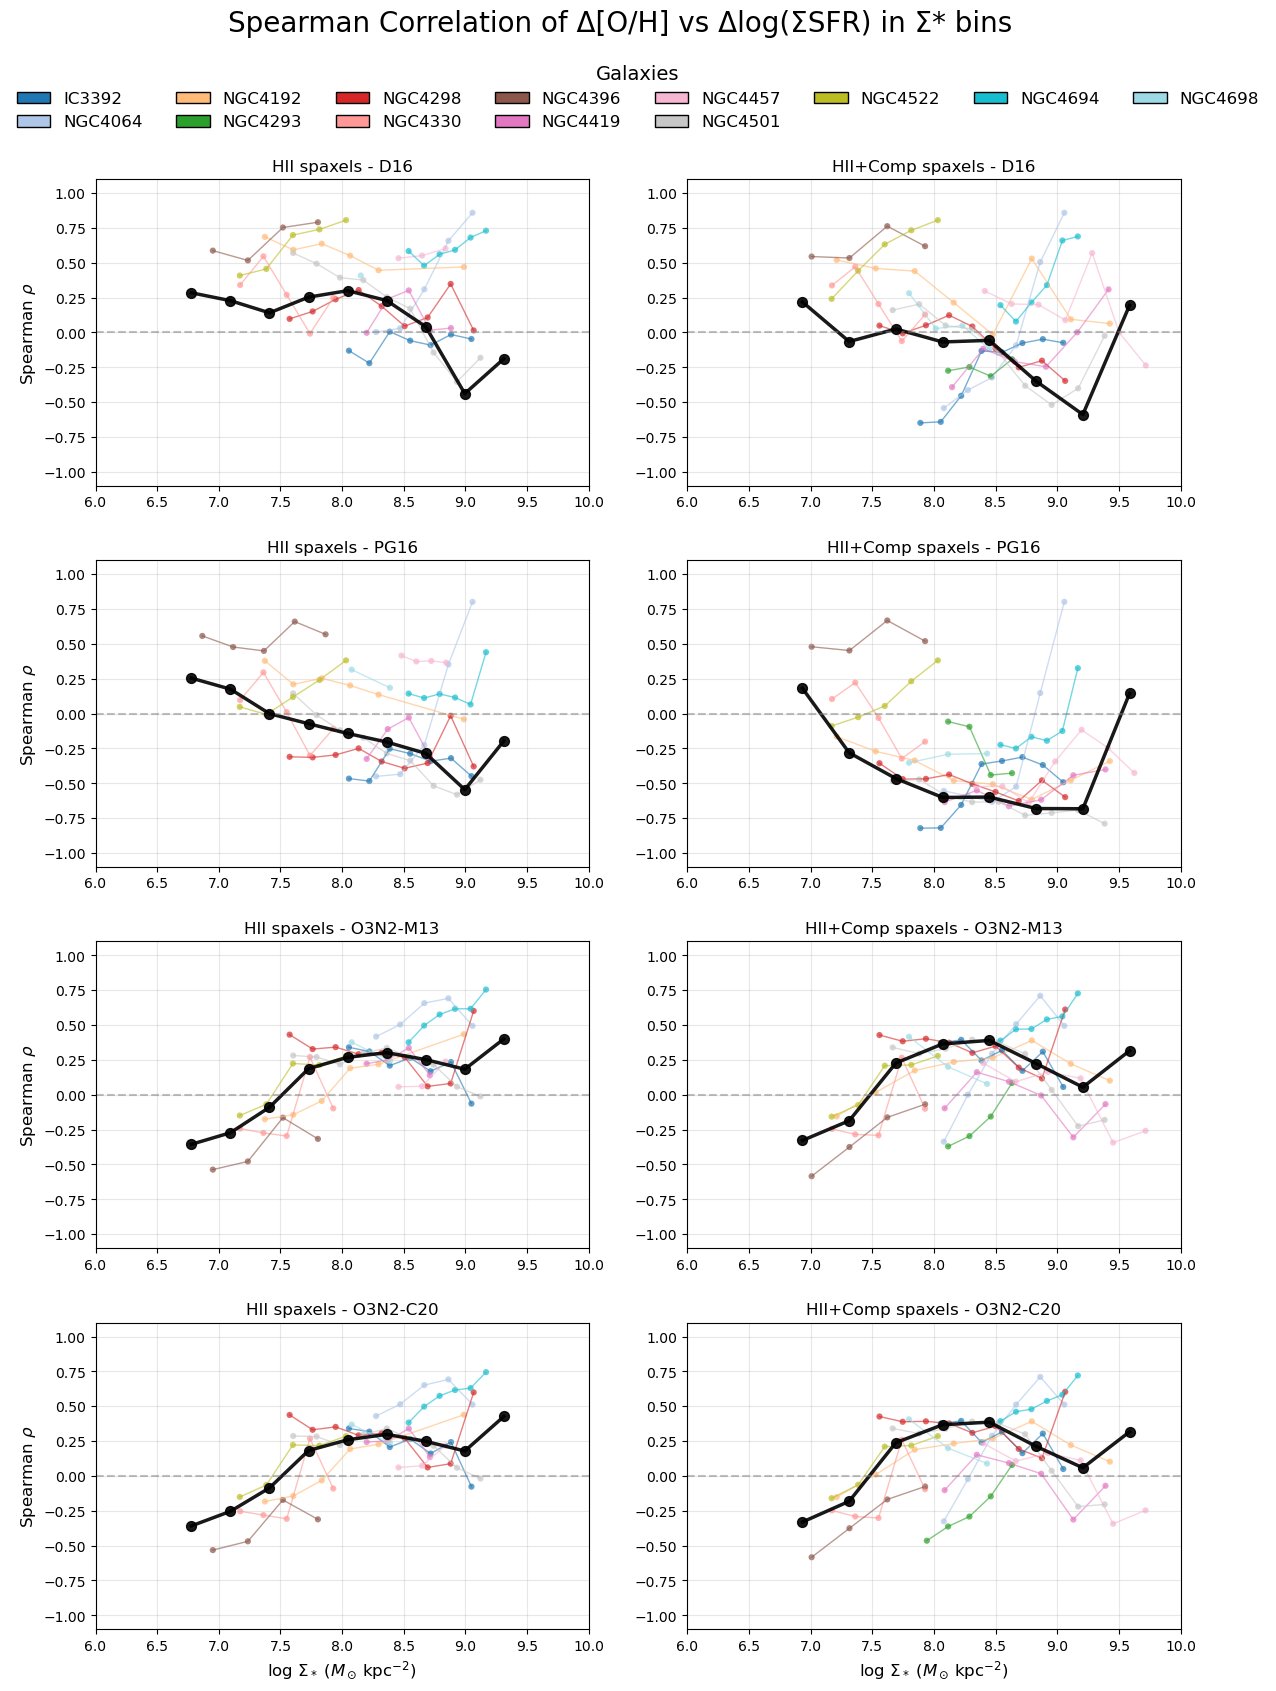

In [4]:
# ------------------------------------------------------------------
# Offset relations: Spearman rho vs Σ_*
# Layout: 4 rows (Indicators) x 2 columns (HII vs SF)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from scipy.stats import spearmanr
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: load all maps
# ------------------------------------------------------------------
def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for both HII and SF regions"""
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    
    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        return None

    with fits.open(spatial_path) as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
        
    return (sigM, 
            sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF)

# ------------------------------------------------------------------
# Helper: calculate binned statistics
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)
    
    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue
            
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            
    return (np.array(valid_centers), np.array(medians), 
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Helper: Compute Spearman rho track for one dataset
# ------------------------------------------------------------------
def compute_spearman_track(sigM, sigSFR, oh_map, n_bins=12):
    valid_all = np.isfinite(sigM) & np.isfinite(sigSFR) & np.isfinite(oh_map)
    if np.sum(valid_all) == 0:
        return np.array([]), np.array([])

    sigM = sigM[valid_all]
    sigSFR = sigSFR[valid_all]
    oh_map = oh_map[valid_all]

    sigmaM_min = np.nanmin(sigM)
    sigmaM_max = np.nanmax(sigM)
    sigmaM_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_centers = 0.5 * (sigmaM_edges[:-1] + sigmaM_edges[1:])
    
    valid_centers = []
    rho_values = []
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM <= sigmaM_edges[i+1])
        else:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i+1])
            
        if np.sum(bin_mask) <= 20: # Min pixels check
            continue
            
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_map[bin_mask]
        
        # Offsets
        sfr_off = sfr_bin - np.mean(sfr_bin)
        oh_off = oh_bin - np.mean(oh_bin)
        
        # 95% contour logic
        try:
            H, xedges, yedges = np.histogram2d(sfr_off, oh_off, bins=30, density=True)
            H_flat = H.flatten()
            H_sorted = np.sort(H_flat)[::-1]
            H_cumsum = np.cumsum(H_sorted)
            H_cumsum /= H_cumsum[-1]
            threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
            
            x_idx = np.searchsorted(xedges, sfr_off, side='right') - 1
            y_idx = np.searchsorted(yedges, oh_off, side='right') - 1
            x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
            y_idx = np.clip(y_idx, 0, H.shape[1] - 1)
            
            inside = H[x_idx, y_idx] >= threshold_95
        except:
            inside = np.ones_like(sfr_off, dtype=bool)
            
        # Trend check
        x_trend = sfr_off[inside]
        y_trend = oh_off[inside]
        centers, _, _, _ = calculate_binned_stats(x_trend, y_trend, bin_width=0.2, min_unique=20)
        
        if centers.size >= 2 and np.sum(inside) > 2:
            try:
                rho, _ = spearmanr(sfr_off[inside], oh_off[inside])
                if np.isfinite(rho):
                    valid_centers.append(sigmaM_centers[i])
                    rho_values.append(rho)
            except:
                pass
                
    return np.array(valid_centers), np.array(rho_values)

# ------------------------------------------------------------------
# Main processing
# ------------------------------------------------------------------
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Storage for results
# Structure: results[region][indicator] = { 'galaxies': {gal_name: (x, y)}, 'global': (x, y) }
results = {
    'HII': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']},
    'SF': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']}
}

print("Processing galaxies...")
for gal in galaxies:
    data = load_maps_all_calibrations(gal)
    if data is None:
        continue
        
    (sigM, 
     sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
     sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF) = data
     
    # Map indicators to data
    maps = {
        'HII': {
            'D16': (sigM, sigSFR_HII, oh_d16_HII),
            'PG16': (sigM, sigSFR_HII, oh_pg16_HII),
            'O3N2-M13': (sigM, sigSFR_HII, oh_o3n2_m13_HII),
            'O3N2-C20': (sigM, sigSFR_HII, oh_o3n2_c20_HII)
        },
        'SF': {
            'D16': (sigM, sigSFR_SF, oh_d16_SF),
            'PG16': (sigM, sigSFR_SF, oh_pg16_SF),
            'O3N2-M13': (sigM, sigSFR_SF, oh_o3n2_m13_SF),
            'O3N2-C20': (sigM, sigSFR_SF, oh_o3n2_c20_SF)
        }
    }
    
    for reg in ['HII', 'SF']:
        for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
            sM, sSFR, oh = maps[reg][ind]
            
            # Compute per-galaxy track
            x, y = compute_spearman_track(sM, sSFR, oh)
            if len(x) > 0:
                results[reg][ind]['galaxies'][gal] = (x, y)
                
            # Collect global pixels
            valid = np.isfinite(sM) & np.isfinite(sSFR) & np.isfinite(oh)
            if np.sum(valid) > 0:
                results[reg][ind]['global_pixels']['sigM'].extend(sM[valid])
                results[reg][ind]['global_pixels']['sigSFR'].extend(sSFR[valid])
                results[reg][ind]['global_pixels']['oh'].extend(oh[valid])

# Compute global tracks
print("Computing global trends...")
for reg in ['HII', 'SF']:
    for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
        g_data = results[reg][ind]['global_pixels']
        if len(g_data['sigM']) > 0:
            x, y = compute_spearman_track(
                np.array(g_data['sigM']), 
                np.array(g_data['sigSFR']), 
                np.array(g_data['oh'])
            )
            results[reg][ind]['global_track'] = (x, y)
        else:
            results[reg][ind]['global_track'] = (np.array([]), np.array([]))

# ------------------------------------------------------------------
# Plotting
# ------------------------------------------------------------------
fig = plt.figure(figsize=(14, 20))
gs = gridspec.GridSpec(5, 2, height_ratios=[0.05, 1, 1, 1, 1], hspace=0.3, wspace=0.2)

# Legend axis
ax_legend = fig.add_subplot(gs[0, :])
ax_legend.axis('off')
legend_elements = [Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal) for gal in galaxies]
ax_legend.legend(handles=legend_elements, loc='center', ncol=min(len(galaxies), 8), 
                 frameon=False, fontsize=12, title='Galaxies', title_fontsize=14)

indicators = ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']
regions = ['HII', 'SF']
region_labels = {'HII': 'HII spaxels', 'SF': 'HII+Comp spaxels'}

for row, ind in enumerate(indicators):
    for col, reg in enumerate(regions):
        ax = fig.add_subplot(gs[row + 1, col])
        
        # Plot individual galaxies
        for gal, (x, y) in results[reg][ind]['galaxies'].items():
            color = galaxy_color_dict[gal]
            # Sort x for plotting lines
            idx = np.argsort(x)
            ax.plot(x[idx], y[idx], color=color, alpha=0.6, linewidth=1)
            ax.scatter(x[idx], y[idx], color=color, s=20, alpha=0.7, edgecolors='none')
            
        # Plot global trend
        gx, gy = results[reg][ind].get('global_track', ([], []))
        if len(gx) > 0:
            idx = np.argsort(gx)
            ax.plot(gx[idx], gy[idx], color='black', linewidth=2.5, alpha=0.9, label='Global')
            ax.scatter(gx[idx], gy[idx], color='black', s=50, alpha=0.9, zorder=10)
            
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_ylim(-1.1, 1.1)
        ax.set_xlim(6, 10)
        
        if row == 3:
            ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        
        if col == 0:
            ax.set_ylabel(r'Spearman $\rho$', fontsize=12)
            
        ax.set_title(f'{region_labels[reg]} - {ind}', fontsize=12)
        ax.grid(True, alpha=0.3)

fig.suptitle('Spearman Correlation of Δ[O/H] vs Δlog(ΣSFR) in Σ* bins', fontsize=20, y=0.92)
plt.show()

Processing 13 galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Computing global Spearman trends...
Computing global Spearman trends...


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_87520/4213269689.py:427: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


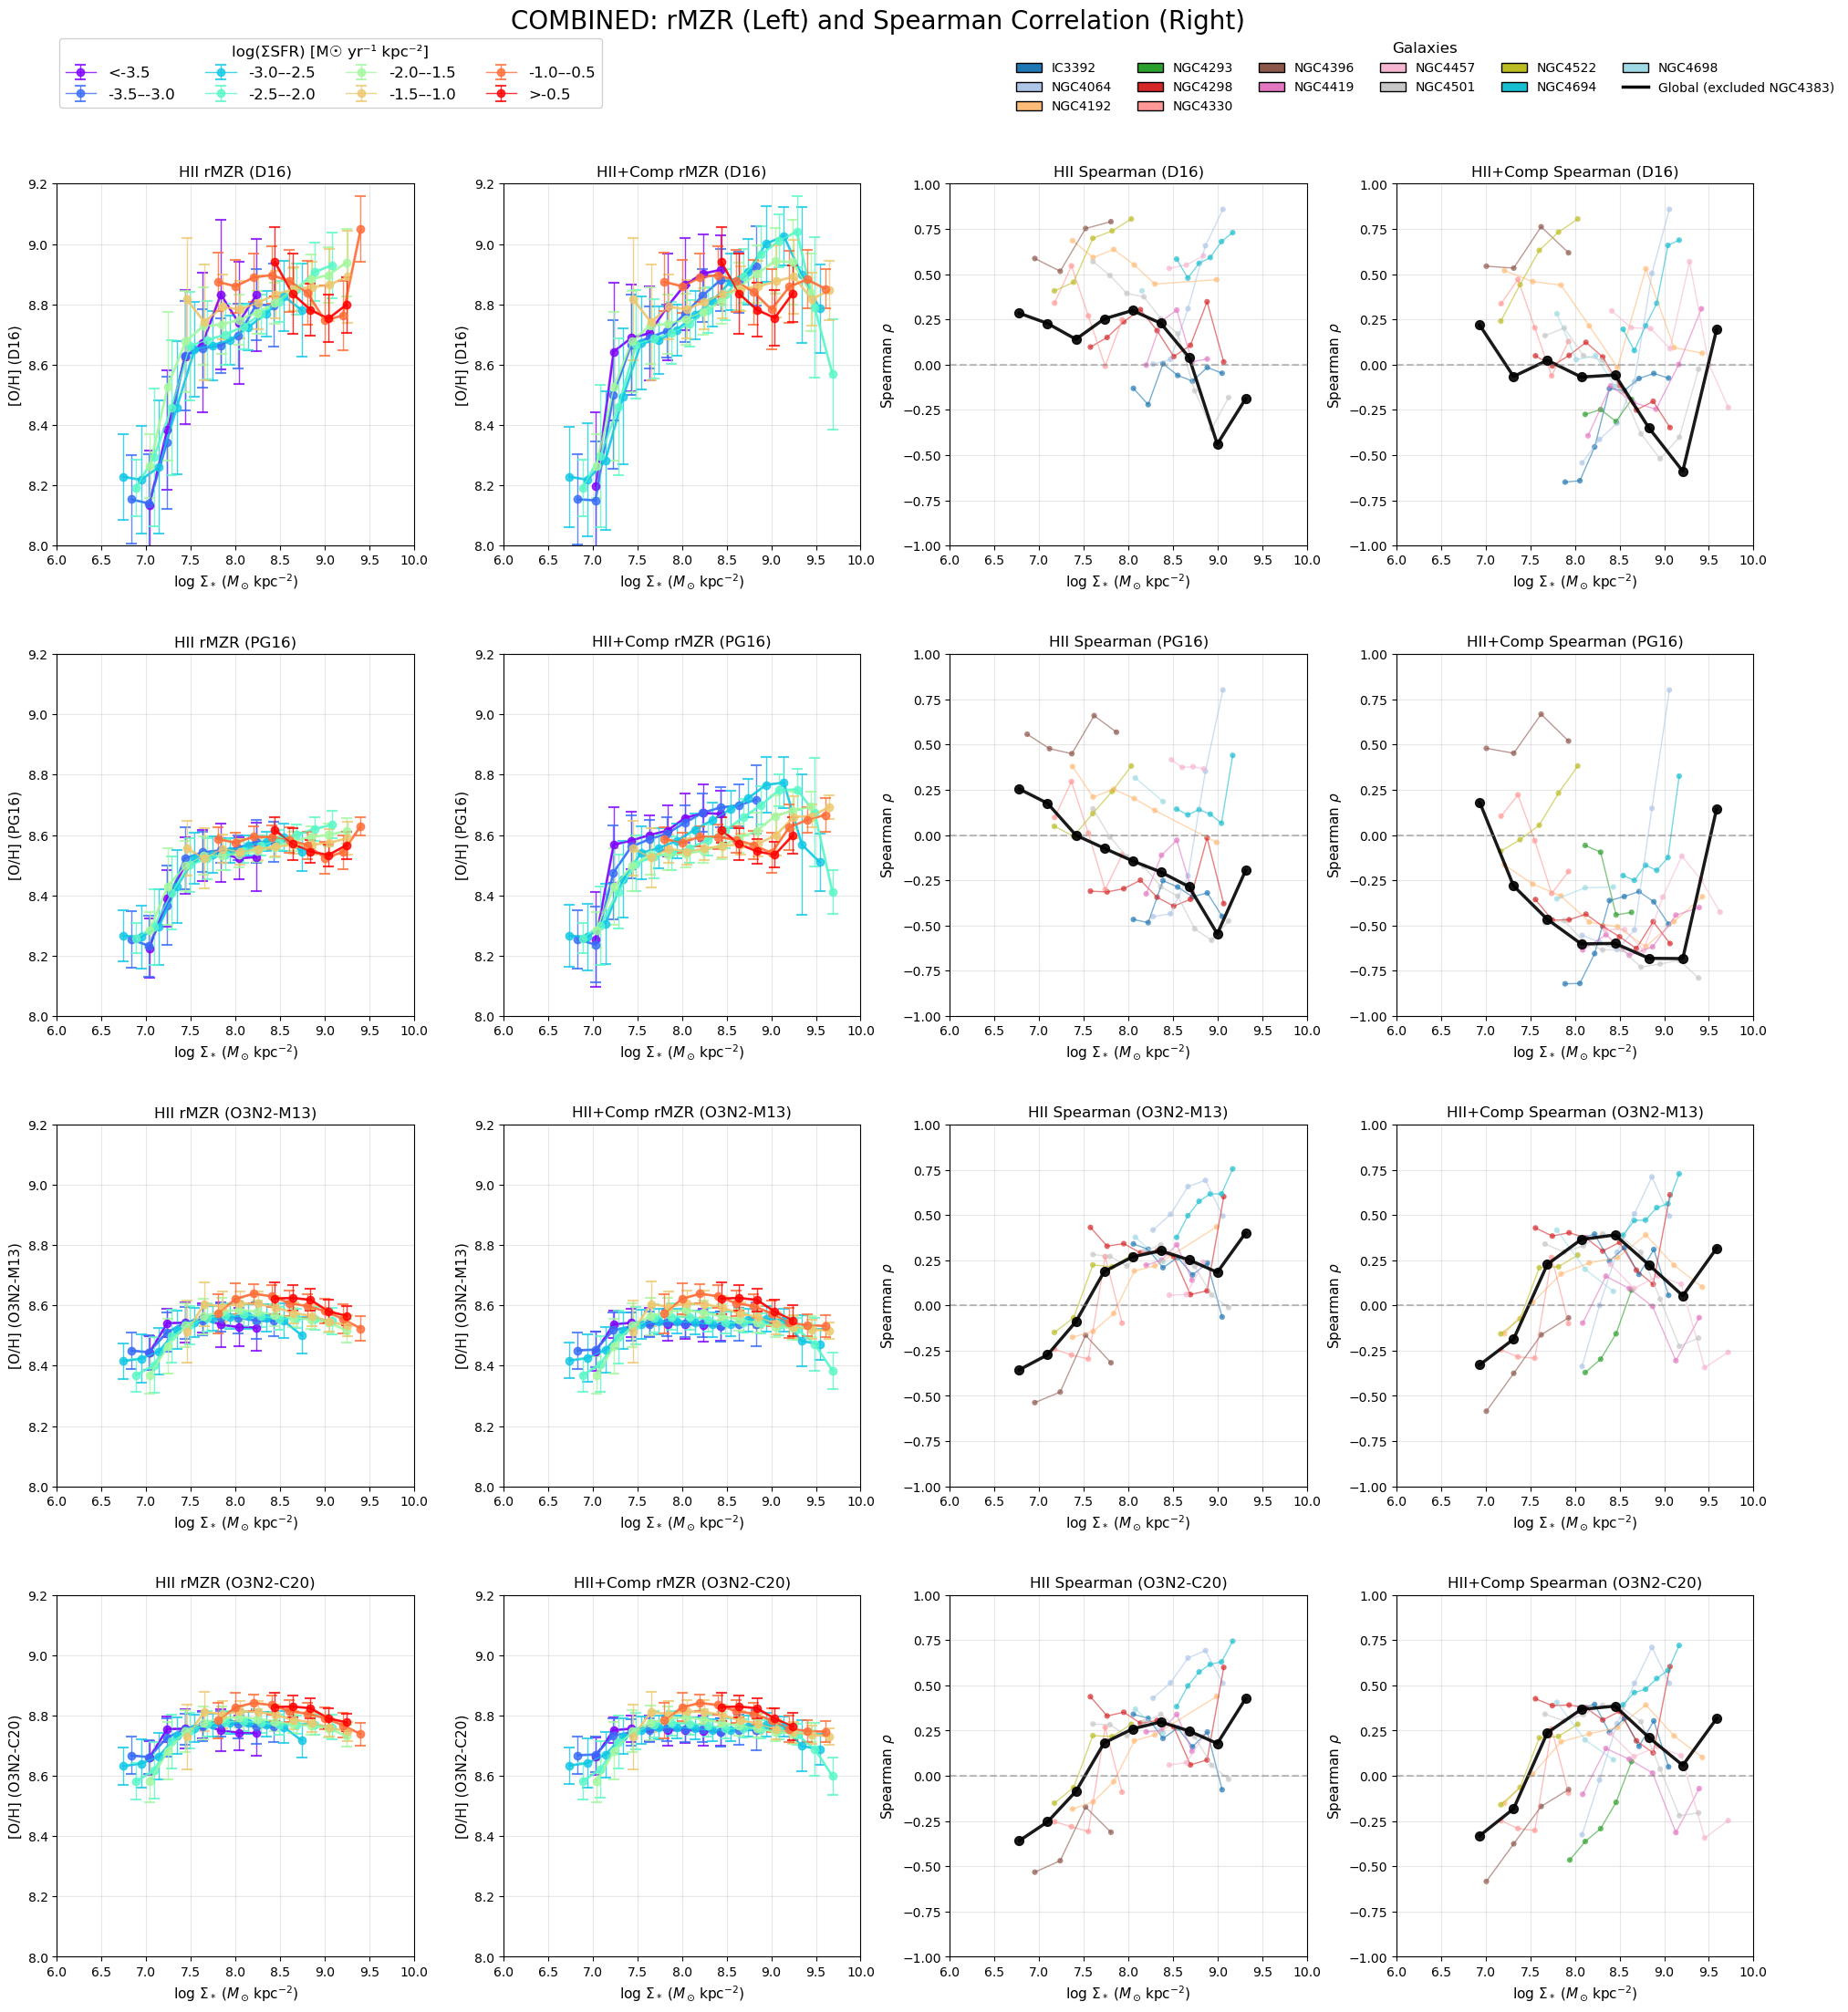

In [10]:
# ------------------------------------------------------------------
# COMBINED FIGURE: rMZR (Cols 1-2) and Spearman rho (Cols 3-4)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
from scipy.stats import spearmanr
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import matplotlib.lines as mlines

# ==========================================
# PART 1: FUNCTIONS & SETUP
# ==========================================

def load_maps_mzr(gal):
    """Load all metallicity calibrations for both HII and SF regions (MZR version)"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
        # Emission lines
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
            HB4861_FLUX_corr, HA6562_FLUX_corr, OIII5006_FLUX_corr, 
            NII6583_FLUX_corr, SII6716_FLUX_corr, SII6730_FLUX_corr)

def calculate_binned_stats_mzr(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins (MZR version)"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

def calculate_binned_stats_spearman(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins (Spearman version)"""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)
    
    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue
            
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            
    return (np.array(valid_centers), np.array(medians), 
            np.array(stds), np.array(counts))

def compute_spearman_track(sigM, sigSFR, oh_map, n_bins=12):
    valid_all = np.isfinite(sigM) & np.isfinite(sigSFR) & np.isfinite(oh_map)
    if np.sum(valid_all) == 0:
        return np.array([]), np.array([])

    sigM = sigM[valid_all]
    sigSFR = sigSFR[valid_all]
    oh_map = oh_map[valid_all]

    sigmaM_min = np.nanmin(sigM)
    sigmaM_max = np.nanmax(sigM)
    sigmaM_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_centers = 0.5 * (sigmaM_edges[:-1] + sigmaM_edges[1:])
    
    valid_centers = []
    rho_values = []
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM <= sigmaM_edges[i+1])
        else:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i+1])
            
        if np.sum(bin_mask) <= 20: 
            continue
            
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_map[bin_mask]
        
        sfr_off = sfr_bin - np.mean(sfr_bin)
        oh_off = oh_bin - np.mean(oh_bin)
        
        try:
            H, xedges, yedges = np.histogram2d(sfr_off, oh_off, bins=30, density=True)
            H_flat = H.flatten()
            H_sorted = np.sort(H_flat)[::-1]
            H_cumsum = np.cumsum(H_sorted)
            H_cumsum /= H_cumsum[-1]
            threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
            
            x_idx = np.searchsorted(xedges, sfr_off, side='right') - 1
            y_idx = np.searchsorted(yedges, oh_off, side='right') - 1
            x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
            y_idx = np.clip(y_idx, 0, H.shape[1] - 1)
            
            inside = H[x_idx, y_idx] >= threshold_95
        except:
            inside = np.ones_like(sfr_off, dtype=bool)
            
        x_trend = sfr_off[inside]
        y_trend = oh_off[inside]
        centers, _, _, _ = calculate_binned_stats_spearman(x_trend, y_trend, bin_width=0.2, min_unique=20)
        
        if centers.size >= 2 and np.sum(inside) > 2:
            try:
                rho, _ = spearmanr(sfr_off[inside], oh_off[inside])
                if np.isfinite(rho):
                    valid_centers.append(sigmaM_centers[i])
                    rho_values.append(rho)
            except:
                pass
                
    return np.array(valid_centers), np.array(rho_values)

# ==========================================
# PART 2: DATA COLLECTION
# ==========================================

# Get galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]
print(f"Processing {len(galaxies)} galaxies: {', '.join(galaxies)}")

# --- MZR Data Containers ---
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

all_logSigmaM_SF = []
all_logSigmaSFR_SF = []
all_oh_d16_SF = []
all_oh_pg16_SF = []
all_oh_o3n2_m13_SF = []
all_oh_o3n2_c20_SF = []

all_logSFR_hii = [] # For binning
all_logSFR_sf = []

# --- Spearman Data Containers ---
spearman_results = {
    'HII': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']},
    'SF': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']}
}

print("Collecting data...")
for gal in galaxies:
    # Load data using the MZR loader (it has everything)
    try:
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
         logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
         HB, HA, OIII, NII, SII6716, SII6730) = load_maps_mzr(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    # --- Process MZR Data ---
    common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))
    
    common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                      np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                      np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF))
    
    # Append MZR data
    all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
    all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
    all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
    all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
    all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
    all_logSFR_hii.extend(logSigmaSFR_HII[common_mask_HII].flatten())
    
    all_logSigmaM_SF.extend(logSigmaM[common_mask_SF].flatten())
    all_logSigmaSFR_SF.extend(logSigmaSFR_SF[common_mask_SF].flatten())
    all_oh_d16_SF.extend(oh_d16_SF[common_mask_SF].flatten())
    all_oh_pg16_SF.extend(oh_pg16_SF[common_mask_SF].flatten())
    all_oh_o3n2_m13_SF.extend(oh_o3n2_m13_SF[common_mask_SF].flatten())
    all_oh_o3n2_c20_SF.extend(oh_o3n2_c20_SF[common_mask_SF].flatten())
    all_logSFR_sf.extend(logSigmaSFR_SF[common_mask_SF].flatten())

    # --- Process Spearman Data ---
    maps = {
        'HII': {
            'D16': (logSigmaM, logSigmaSFR_HII, oh_d16_HII),
            'PG16': (logSigmaM, logSigmaSFR_HII, oh_pg16_HII),
            'O3N2-M13': (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII),
            'O3N2-C20': (logSigmaM, logSigmaSFR_HII, oh_o3n2_c20_HII)
        },
        'SF': {
            'D16': (logSigmaM, logSigmaSFR_SF, oh_d16_SF),
            'PG16': (logSigmaM, logSigmaSFR_SF, oh_pg16_SF),
            'O3N2-M13': (logSigmaM, logSigmaSFR_SF, oh_o3n2_m13_SF),
            'O3N2-C20': (logSigmaM, logSigmaSFR_SF, oh_o3n2_c20_SF)
        }
    }
    
    for reg in ['HII', 'SF']:
        for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
            sM, sSFR, oh = maps[reg][ind]
            # Compute per-galaxy track
            x, y = compute_spearman_track(sM, sSFR, oh)
            if len(x) > 0:
                spearman_results[reg][ind]['galaxies'][gal] = (x, y)
            # Collect global pixels
            valid = np.isfinite(sM) & np.isfinite(sSFR) & np.isfinite(oh)
            if np.sum(valid) > 0:
                spearman_results[reg][ind]['global_pixels']['sigM'].extend(sM[valid])
                spearman_results[reg][ind]['global_pixels']['sigSFR'].extend(sSFR[valid])
                spearman_results[reg][ind]['global_pixels']['oh'].extend(oh[valid])

# Convert MZR lists to arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)
all_logSFR_hii = np.array(all_logSFR_hii)

all_logSigmaM_SF = np.array(all_logSigmaM_SF)
all_logSigmaSFR_SF = np.array(all_logSigmaSFR_SF)
all_oh_d16_SF = np.array(all_oh_d16_SF)
all_oh_pg16_SF = np.array(all_oh_pg16_SF)
all_oh_o3n2_m13_SF = np.array(all_oh_o3n2_m13_SF)
all_oh_o3n2_c20_SF = np.array(all_oh_o3n2_c20_SF)
all_logSFR_sf = np.array(all_logSFR_sf)

# Compute global Spearman tracks
print("Computing global Spearman trends...")
for reg in ['HII', 'SF']:
    for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
        g_data = spearman_results[reg][ind]['global_pixels']
        if len(g_data['sigM']) > 0:
            x, y = compute_spearman_track(
                np.array(g_data['sigM']), 
                np.array(g_data['sigSFR']), 
                np.array(g_data['oh'])
            )
            spearman_results[reg][ind]['global_track'] = (x, y)
        else:
            spearman_results[reg][ind]['global_track'] = (np.array([]), np.array([]))

# ==========================================
# PART 3: PLOTTING
# ==========================================

# Setup MZR bins
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
n_bins = len(sfr_bin_edges) - 1
mzr_colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']

# Setup Galaxy colors (using ALL galaxies to preserve color mapping)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Create Figure
fig = plt.figure(figsize=(24, 24))
# 4 rows, 4 columns. Top margin for legends.
gs = gridspec.GridSpec(4, 4, figure=fig, wspace=0.25, hspace=0.3, top=0.92)

calibrations = ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']
mzr_data_HII = [all_oh_d16_HII, all_oh_pg16_HII, all_oh_o3n2_m13_HII, all_oh_o3n2_c20_HII]
mzr_data_SF = [all_oh_d16_SF, all_oh_pg16_SF, all_oh_o3n2_m13_SF, all_oh_o3n2_c20_SF]

mzr_legend_handles = []
mzr_legend_labels = []

for row_idx, calib_name in enumerate(calibrations):
    # --- COL 0 & 1: MZR ---
    ax_mzr_HII = fig.add_subplot(gs[row_idx, 0])
    ax_mzr_SF = fig.add_subplot(gs[row_idx, 1])
    
    oh_HII = mzr_data_HII[row_idx]
    oh_SF = mzr_data_SF[row_idx]
    
    # Plot MZR HII
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
        if np.sum(in_bin) >= 10:
            mass_centers, medians, stds, counts, valid_idx = calculate_binned_stats_mzr(
                all_logSigmaM_HII[in_bin], oh_HII[in_bin])
            if len(mass_centers) > 0:
                err = ax_mzr_HII.errorbar(mass_centers, medians, yerr=stds, color=mzr_colors[i], 
                               marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                if row_idx == 0 and len(mzr_legend_handles) < n_bins:
                     mzr_legend_handles.append(err)
                     mzr_legend_labels.append(bin_labels[i])
                for j in range(len(valid_idx) - 1):
                    if valid_idx[j + 1] - valid_idx[j] == 1:
                        ax_mzr_HII.plot([mass_centers[j], mass_centers[j + 1]], 
                                   [medians[j], medians[j + 1]], color=mzr_colors[i], linewidth=2, alpha=0.8)
    
    # Plot MZR SF
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_SF >= sfr_bin_edges[i]) & (all_logSigmaSFR_SF < sfr_bin_edges[i+1])
        if np.sum(in_bin) >= 10:
            mass_centers, medians, stds, counts, valid_idx = calculate_binned_stats_mzr(
                all_logSigmaM_SF[in_bin], oh_SF[in_bin])
            if len(mass_centers) > 0:
                ax_mzr_SF.errorbar(mass_centers, medians, yerr=stds, color=mzr_colors[i], 
                              marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_idx) - 1):
                    if valid_idx[j + 1] - valid_idx[j] == 1:
                        ax_mzr_SF.plot([mass_centers[j], mass_centers[j + 1]], 
                                  [medians[j], medians[j + 1]], color=mzr_colors[i], linewidth=2, alpha=0.8)

    # Format MZR Axes
    for ax, region_label in zip([ax_mzr_HII, ax_mzr_SF], ['HII', 'HII+Comp']):
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
        ax.set_ylabel(f'[O/H] ({calib_name})', fontsize=11)
        ax.set_xlim(6, 10)
        ax.set_ylim(8.0, 9.2) # Fixed range for consistency
        ax.set_title(f'{region_label} rMZR ({calib_name})', fontsize=12)
        ax.grid(True, alpha=0.3)

    # --- COL 2 & 3: Spearman ---
    ax_sp_HII = fig.add_subplot(gs[row_idx, 2])
    ax_sp_SF = fig.add_subplot(gs[row_idx, 3])
    
    for ax, region_key, region_label in zip([ax_sp_HII, ax_sp_SF], ['HII', 'SF'], ['HII', 'HII+Comp']):
        # Plot individual galaxies
        for gal, (x, y) in spearman_results[region_key][calib_name]['galaxies'].items():
            color = galaxy_color_dict[gal]
            idx = np.argsort(x)
            ax.plot(x[idx], y[idx], color=color, alpha=0.6, linewidth=1)
            ax.scatter(x[idx], y[idx], color=color, s=20, alpha=0.7, edgecolors='none')
            
        # Plot global trend
        gx, gy = spearman_results[region_key][calib_name].get('global_track', ([], []))
        if len(gx) > 0:
            idx = np.argsort(gx)
            ax.plot(gx[idx], gy[idx], color='black', linewidth=2.5, alpha=0.9)
            ax.scatter(gx[idx], gy[idx], color='black', s=50, alpha=0.9, zorder=10)
            
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_ylim(-1.0, 1.0)
        ax.set_xlim(6, 10)
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
        ax.set_ylabel(r'Spearman $\rho$', fontsize=11)
        ax.set_title(f'{region_label} Spearman ({calib_name})', fontsize=12)
        ax.grid(True, alpha=0.3)

# --- LEGENDS ---
# 1. MZR Legend (Left side)
fig.legend(mzr_legend_handles, mzr_legend_labels, loc='upper center', bbox_to_anchor=(0.25, 0.99),
          ncol=4, fontsize=12, framealpha=0.9, 
          title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=12)

# 2. Spearman Legend (Right side)
spearman_legend_elements = [Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal) for gal in galaxies]
spearman_legend_elements.append(mlines.Line2D([], [], color='black', lw=2.5, label='Global (excluded NGC4383)'))

fig.legend(handles=spearman_legend_elements, loc='upper center', bbox_to_anchor=(0.75, 0.99),
           ncol=min(len(galaxies)+1, 6), frameon=False, fontsize=10, title='Galaxies', title_fontsize=12)

fig.suptitle(f'COMBINED: rMZR (Left) and Spearman Correlation (Right)', fontsize=20, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


Processing 13 galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Computing global Spearman trends...
Computing global Spearman trends...


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_87520/3465183546.py:388: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


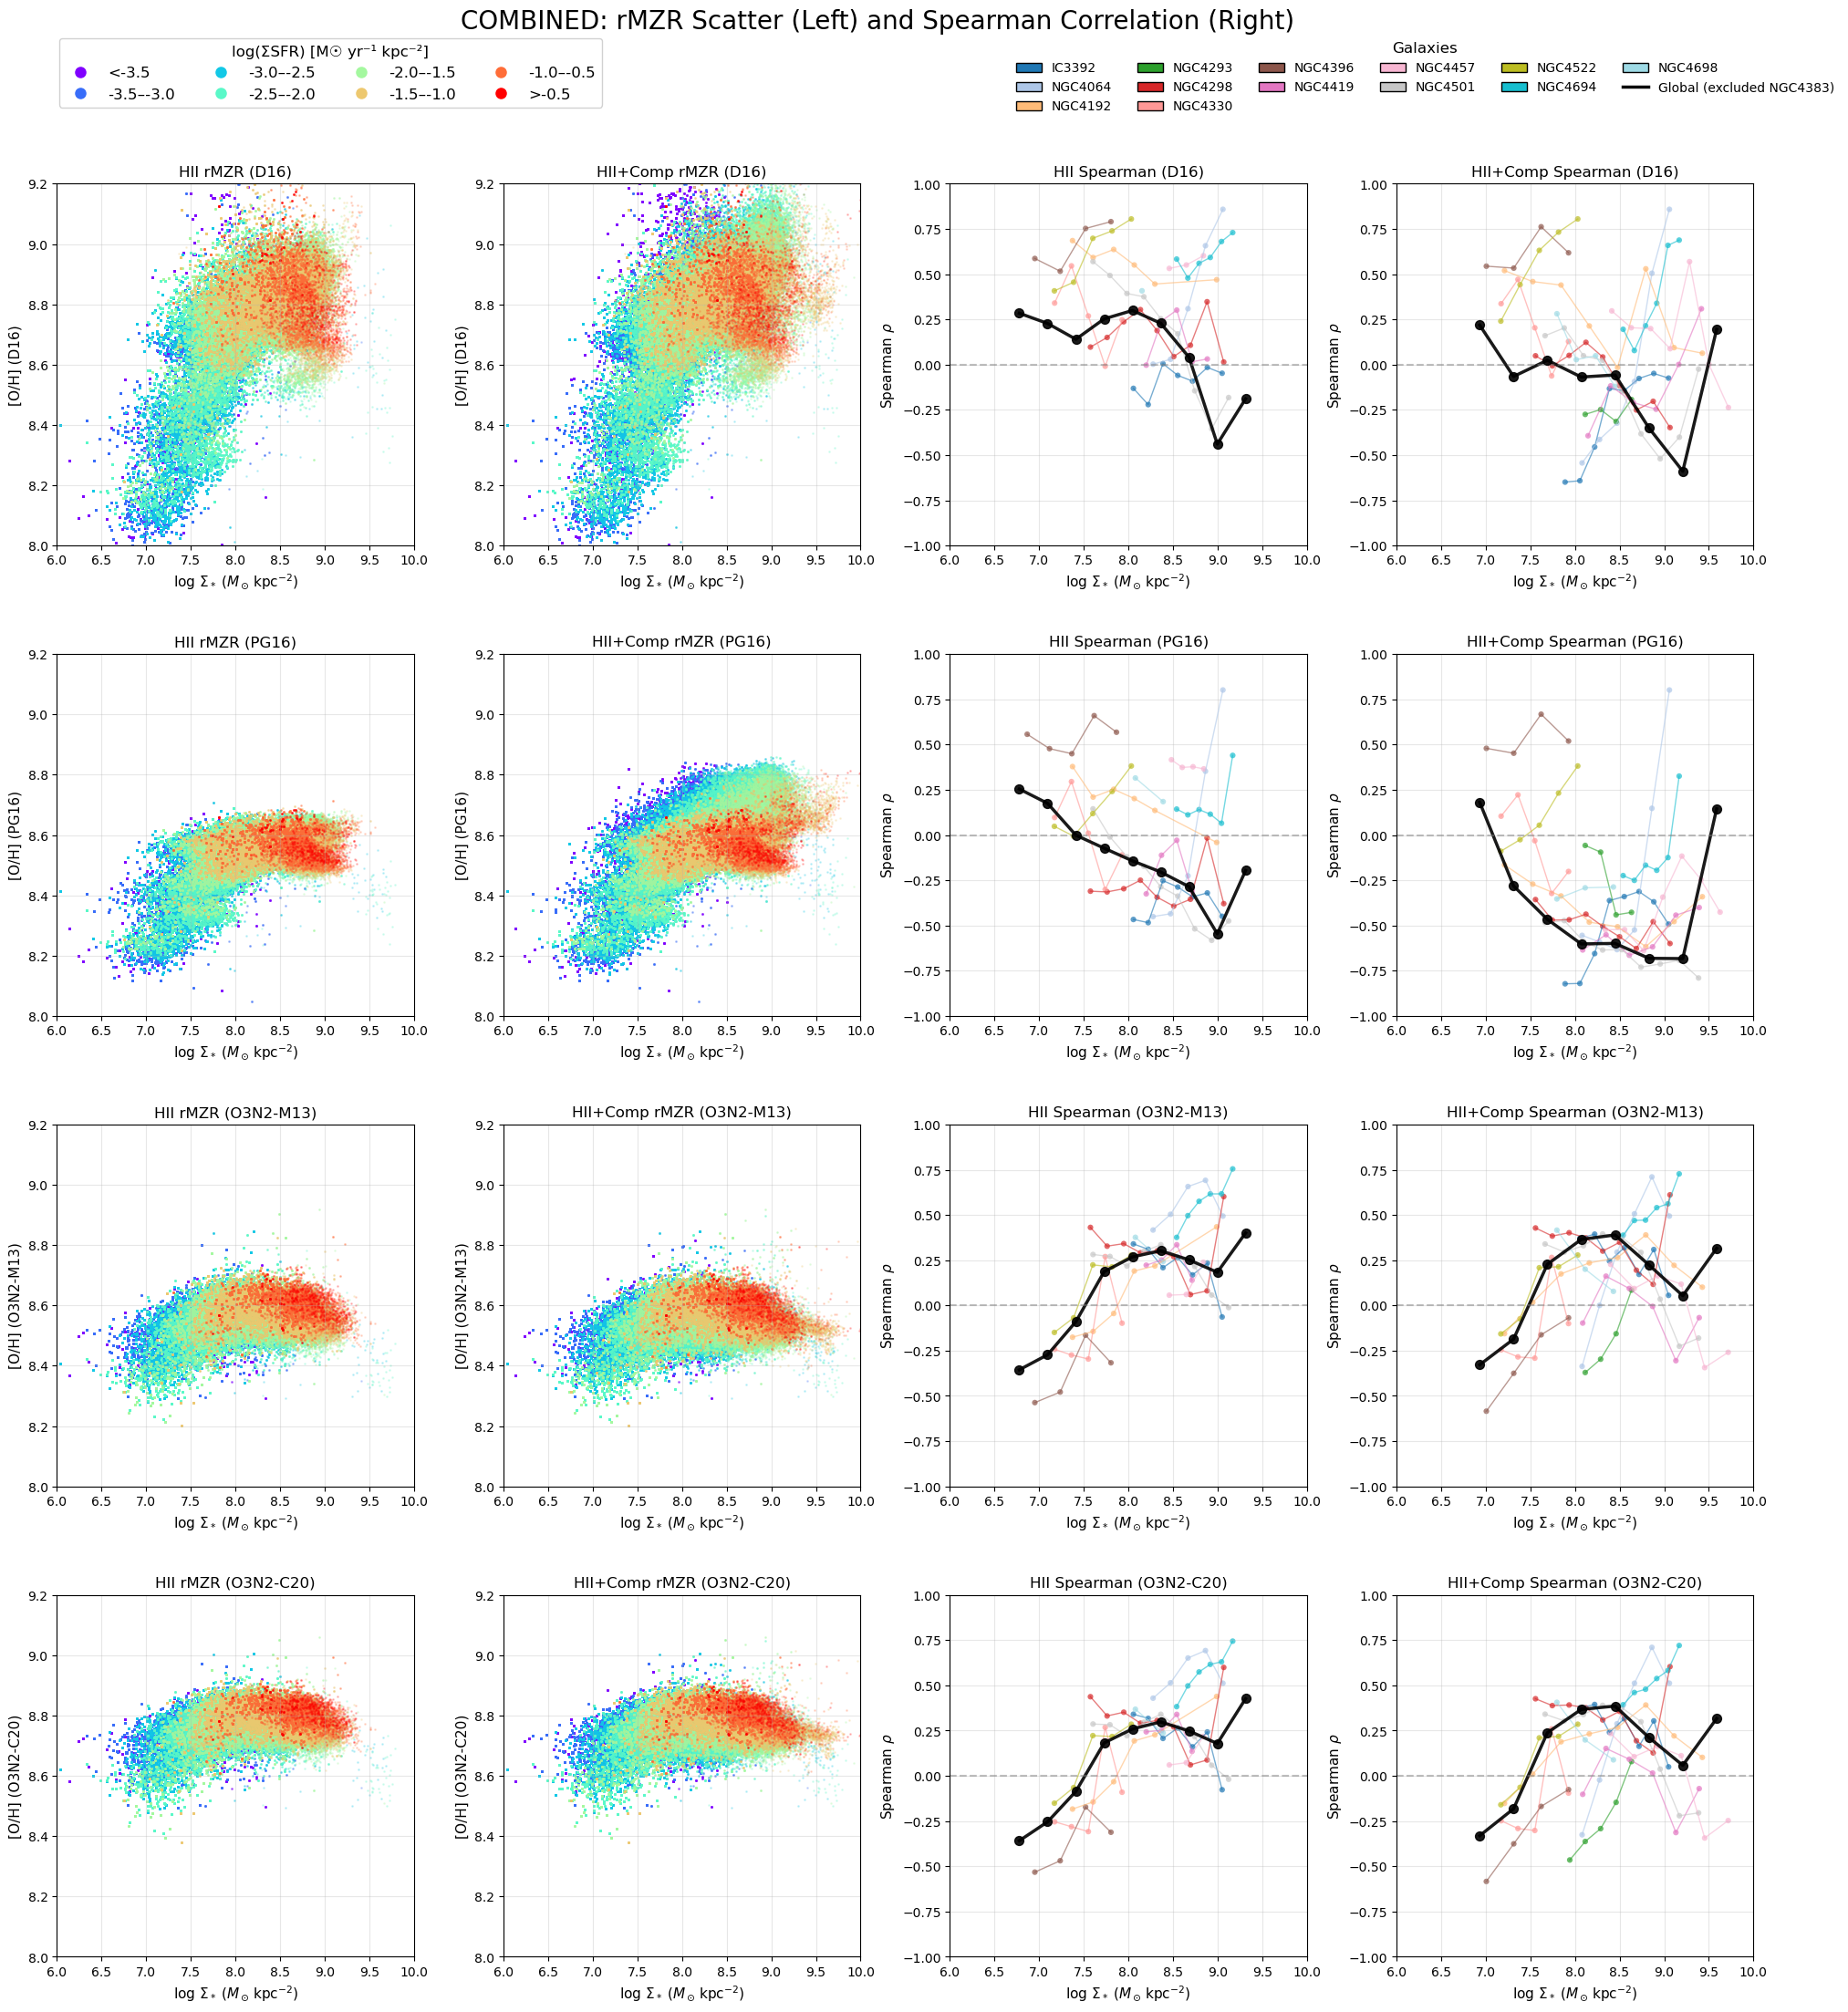

In [11]:
# ------------------------------------------------------------------
# COMBINED FIGURE: rMZR Scatter (Cols 1-2) and Spearman rho (Cols 3-4)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
from scipy.stats import spearmanr
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import matplotlib.lines as mlines

# ==========================================
# PART 1: FUNCTIONS & SETUP
# ==========================================

def load_maps_mzr(gal):
    """Load all metallicity calibrations for both HII and SF regions (MZR version)"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
        # Emission lines
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
            HB4861_FLUX_corr, HA6562_FLUX_corr, OIII5006_FLUX_corr, 
            NII6583_FLUX_corr, SII6716_FLUX_corr, SII6730_FLUX_corr)

def calculate_binned_stats_spearman(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins (Spearman version)"""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)
    
    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue
            
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            
    return (np.array(valid_centers), np.array(medians), 
            np.array(stds), np.array(counts))

def compute_spearman_track(sigM, sigSFR, oh_map, n_bins=12):
    valid_all = np.isfinite(sigM) & np.isfinite(sigSFR) & np.isfinite(oh_map)
    if np.sum(valid_all) == 0:
        return np.array([]), np.array([])

    sigM = sigM[valid_all]
    sigSFR = sigSFR[valid_all]
    oh_map = oh_map[valid_all]

    sigmaM_min = np.nanmin(sigM)
    sigmaM_max = np.nanmax(sigM)
    sigmaM_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_centers = 0.5 * (sigmaM_edges[:-1] + sigmaM_edges[1:])
    
    valid_centers = []
    rho_values = []
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM <= sigmaM_edges[i+1])
        else:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i+1])
            
        if np.sum(bin_mask) <= 20: 
            continue
            
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_map[bin_mask]
        
        sfr_off = sfr_bin - np.mean(sfr_bin)
        oh_off = oh_bin - np.mean(oh_bin)
        
        try:
            H, xedges, yedges = np.histogram2d(sfr_off, oh_off, bins=30, density=True)
            H_flat = H.flatten()
            H_sorted = np.sort(H_flat)[::-1]
            H_cumsum = np.cumsum(H_sorted)
            H_cumsum /= H_cumsum[-1]
            threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
            
            x_idx = np.searchsorted(xedges, sfr_off, side='right') - 1
            y_idx = np.searchsorted(yedges, oh_off, side='right') - 1
            x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
            y_idx = np.clip(y_idx, 0, H.shape[1] - 1)
            
            inside = H[x_idx, y_idx] >= threshold_95
        except:
            inside = np.ones_like(sfr_off, dtype=bool)
            
        x_trend = sfr_off[inside]
        y_trend = oh_off[inside]
        centers, _, _, _ = calculate_binned_stats_spearman(x_trend, y_trend, bin_width=0.2, min_unique=20)
        
        if centers.size >= 2 and np.sum(inside) > 2:
            try:
                rho, _ = spearmanr(sfr_off[inside], oh_off[inside])
                if np.isfinite(rho):
                    valid_centers.append(sigmaM_centers[i])
                    rho_values.append(rho)
            except:
                pass
                
    return np.array(valid_centers), np.array(rho_values)

# ==========================================
# PART 2: DATA COLLECTION
# ==========================================

# Get galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]
print(f"Processing {len(galaxies)} galaxies: {', '.join(galaxies)}")

# --- MZR Data Containers ---
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

all_logSigmaM_SF = []
all_logSigmaSFR_SF = []
all_oh_d16_SF = []
all_oh_pg16_SF = []
all_oh_o3n2_m13_SF = []
all_oh_o3n2_c20_SF = []

all_logSFR_hii = [] # For binning
all_logSFR_sf = []

# --- Spearman Data Containers ---
spearman_results = {
    'HII': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']},
    'SF': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']}
}

print("Collecting data...")
for gal in galaxies:
    # Load data using the MZR loader (it has everything)
    try:
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
         logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
         HB, HA, OIII, NII, SII6716, SII6730) = load_maps_mzr(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    # --- Process MZR Data ---
    common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))
    
    common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                      np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                      np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF))
    
    # Append MZR data
    all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
    all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
    all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
    all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
    all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
    all_logSFR_hii.extend(logSigmaSFR_HII[common_mask_HII].flatten())
    
    all_logSigmaM_SF.extend(logSigmaM[common_mask_SF].flatten())
    all_logSigmaSFR_SF.extend(logSigmaSFR_SF[common_mask_SF].flatten())
    all_oh_d16_SF.extend(oh_d16_SF[common_mask_SF].flatten())
    all_oh_pg16_SF.extend(oh_pg16_SF[common_mask_SF].flatten())
    all_oh_o3n2_m13_SF.extend(oh_o3n2_m13_SF[common_mask_SF].flatten())
    all_oh_o3n2_c20_SF.extend(oh_o3n2_c20_SF[common_mask_SF].flatten())
    all_logSFR_sf.extend(logSigmaSFR_SF[common_mask_SF].flatten())

    # --- Process Spearman Data ---
    maps = {
        'HII': {
            'D16': (logSigmaM, logSigmaSFR_HII, oh_d16_HII),
            'PG16': (logSigmaM, logSigmaSFR_HII, oh_pg16_HII),
            'O3N2-M13': (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII),
            'O3N2-C20': (logSigmaM, logSigmaSFR_HII, oh_o3n2_c20_HII)
        },
        'SF': {
            'D16': (logSigmaM, logSigmaSFR_SF, oh_d16_SF),
            'PG16': (logSigmaM, logSigmaSFR_SF, oh_pg16_SF),
            'O3N2-M13': (logSigmaM, logSigmaSFR_SF, oh_o3n2_m13_SF),
            'O3N2-C20': (logSigmaM, logSigmaSFR_SF, oh_o3n2_c20_SF)
        }
    }
    
    for reg in ['HII', 'SF']:
        for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
            sM, sSFR, oh = maps[reg][ind]
            # Compute per-galaxy track
            x, y = compute_spearman_track(sM, sSFR, oh)
            if len(x) > 0:
                spearman_results[reg][ind]['galaxies'][gal] = (x, y)
            # Collect global pixels
            valid = np.isfinite(sM) & np.isfinite(sSFR) & np.isfinite(oh)
            if np.sum(valid) > 0:
                spearman_results[reg][ind]['global_pixels']['sigM'].extend(sM[valid])
                spearman_results[reg][ind]['global_pixels']['sigSFR'].extend(sSFR[valid])
                spearman_results[reg][ind]['global_pixels']['oh'].extend(oh[valid])

# Convert MZR lists to arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)
all_logSFR_hii = np.array(all_logSFR_hii)

all_logSigmaM_SF = np.array(all_logSigmaM_SF)
all_logSigmaSFR_SF = np.array(all_logSigmaSFR_SF)
all_oh_d16_SF = np.array(all_oh_d16_SF)
all_oh_pg16_SF = np.array(all_oh_pg16_SF)
all_oh_o3n2_m13_SF = np.array(all_oh_o3n2_m13_SF)
all_oh_o3n2_c20_SF = np.array(all_oh_o3n2_c20_SF)
all_logSFR_sf = np.array(all_logSFR_sf)

# Compute global Spearman tracks
print("Computing global Spearman trends...")
for reg in ['HII', 'SF']:
    for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
        g_data = spearman_results[reg][ind]['global_pixels']
        if len(g_data['sigM']) > 0:
            x, y = compute_spearman_track(
                np.array(g_data['sigM']), 
                np.array(g_data['sigSFR']), 
                np.array(g_data['oh'])
            )
            spearman_results[reg][ind]['global_track'] = (x, y)
        else:
            spearman_results[reg][ind]['global_track'] = (np.array([]), np.array([]))

# ==========================================
# PART 3: PLOTTING
# ==========================================

# Setup MZR bins
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
n_bins = len(sfr_bin_edges) - 1
mzr_colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']

# Setup Galaxy colors (using ALL galaxies to preserve color mapping)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Create Figure
fig = plt.figure(figsize=(24, 24))
# 4 rows, 4 columns. Top margin for legends.
gs = gridspec.GridSpec(4, 4, figure=fig, wspace=0.25, hspace=0.3, top=0.92)

calibrations = ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']
mzr_data_HII = [all_oh_d16_HII, all_oh_pg16_HII, all_oh_o3n2_m13_HII, all_oh_o3n2_c20_HII]
mzr_data_SF = [all_oh_d16_SF, all_oh_pg16_SF, all_oh_o3n2_m13_SF, all_oh_o3n2_c20_SF]

mzr_legend_handles = []
mzr_legend_labels = []

for row_idx, calib_name in enumerate(calibrations):
    # --- COL 0 & 1: MZR (Scatter) ---
    ax_mzr_HII = fig.add_subplot(gs[row_idx, 0])
    ax_mzr_SF = fig.add_subplot(gs[row_idx, 1])
    
    oh_HII = mzr_data_HII[row_idx]
    oh_SF = mzr_data_SF[row_idx]
    
    # Plot MZR HII (Scatter)
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
        if np.sum(in_bin) > 0:
            ax_mzr_HII.scatter(all_logSigmaM_HII[in_bin], oh_HII[in_bin], 
                               color=mzr_colors[i], s=1, alpha=0.2, rasterized=True)
            
            if row_idx == 0 and len(mzr_legend_handles) < n_bins:
                 mzr_legend_handles.append(mlines.Line2D([], [], color=mzr_colors[i], marker='o', linestyle='None', markersize=8, label=bin_labels[i]))
                 mzr_legend_labels.append(bin_labels[i])
    
    # Plot MZR SF (Scatter)
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_SF >= sfr_bin_edges[i]) & (all_logSigmaSFR_SF < sfr_bin_edges[i+1])
        if np.sum(in_bin) > 0:
            ax_mzr_SF.scatter(all_logSigmaM_SF[in_bin], oh_SF[in_bin], 
                              color=mzr_colors[i], s=1, alpha=0.2, rasterized=True)

    # Format MZR Axes
    for ax, region_label in zip([ax_mzr_HII, ax_mzr_SF], ['HII', 'HII+Comp']):
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
        ax.set_ylabel(f'[O/H] ({calib_name})', fontsize=11)
        ax.set_xlim(6, 10)
        ax.set_ylim(8.0, 9.2) # Fixed range for consistency
        ax.set_title(f'{region_label} rMZR ({calib_name})', fontsize=12)
        ax.grid(True, alpha=0.3)

    # --- COL 2 & 3: Spearman ---
    ax_sp_HII = fig.add_subplot(gs[row_idx, 2])
    ax_sp_SF = fig.add_subplot(gs[row_idx, 3])
    
    for ax, region_key, region_label in zip([ax_sp_HII, ax_sp_SF], ['HII', 'SF'], ['HII', 'HII+Comp']):
        # Plot individual galaxies
        for gal, (x, y) in spearman_results[region_key][calib_name]['galaxies'].items():
            color = galaxy_color_dict[gal]
            idx = np.argsort(x)
            ax.plot(x[idx], y[idx], color=color, alpha=0.6, linewidth=1)
            ax.scatter(x[idx], y[idx], color=color, s=20, alpha=0.7, edgecolors='none')
            
        # Plot global trend
        gx, gy = spearman_results[region_key][calib_name].get('global_track', ([], []))
        if len(gx) > 0:
            idx = np.argsort(gx)
            ax.plot(gx[idx], gy[idx], color='black', linewidth=2.5, alpha=0.9)
            ax.scatter(gx[idx], gy[idx], color='black', s=50, alpha=0.9, zorder=10)
            
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_ylim(-1.0, 1.0)
        ax.set_xlim(6, 10)
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
        ax.set_ylabel(r'Spearman $\rho$', fontsize=11)
        ax.set_title(f'{region_label} Spearman ({calib_name})', fontsize=12)
        ax.grid(True, alpha=0.3)

# --- LEGENDS ---
# 1. MZR Legend (Left side)
fig.legend(mzr_legend_handles, mzr_legend_labels, loc='upper center', bbox_to_anchor=(0.25, 0.99),
          ncol=4, fontsize=12, framealpha=0.9, 
          title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=12)

# 2. Spearman Legend (Right side)
spearman_legend_elements = [Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal) for gal in galaxies]
spearman_legend_elements.append(mlines.Line2D([], [], color='black', lw=2.5, label='Global (excluded NGC4383)'))

fig.legend(handles=spearman_legend_elements, loc='upper center', bbox_to_anchor=(0.75, 0.99),
           ncol=min(len(galaxies)+1, 6), frameon=False, fontsize=10, title='Galaxies', title_fontsize=12)

fig.suptitle(f'COMBINED: rMZR Scatter (Left) and Spearman Correlation (Right)', fontsize=20, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


Processing 13 galaxies (excluding NGC4383 for stats): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Computing global Spearman trends...
Computing global Spearman trends...


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_5779/3754506270.py:557: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


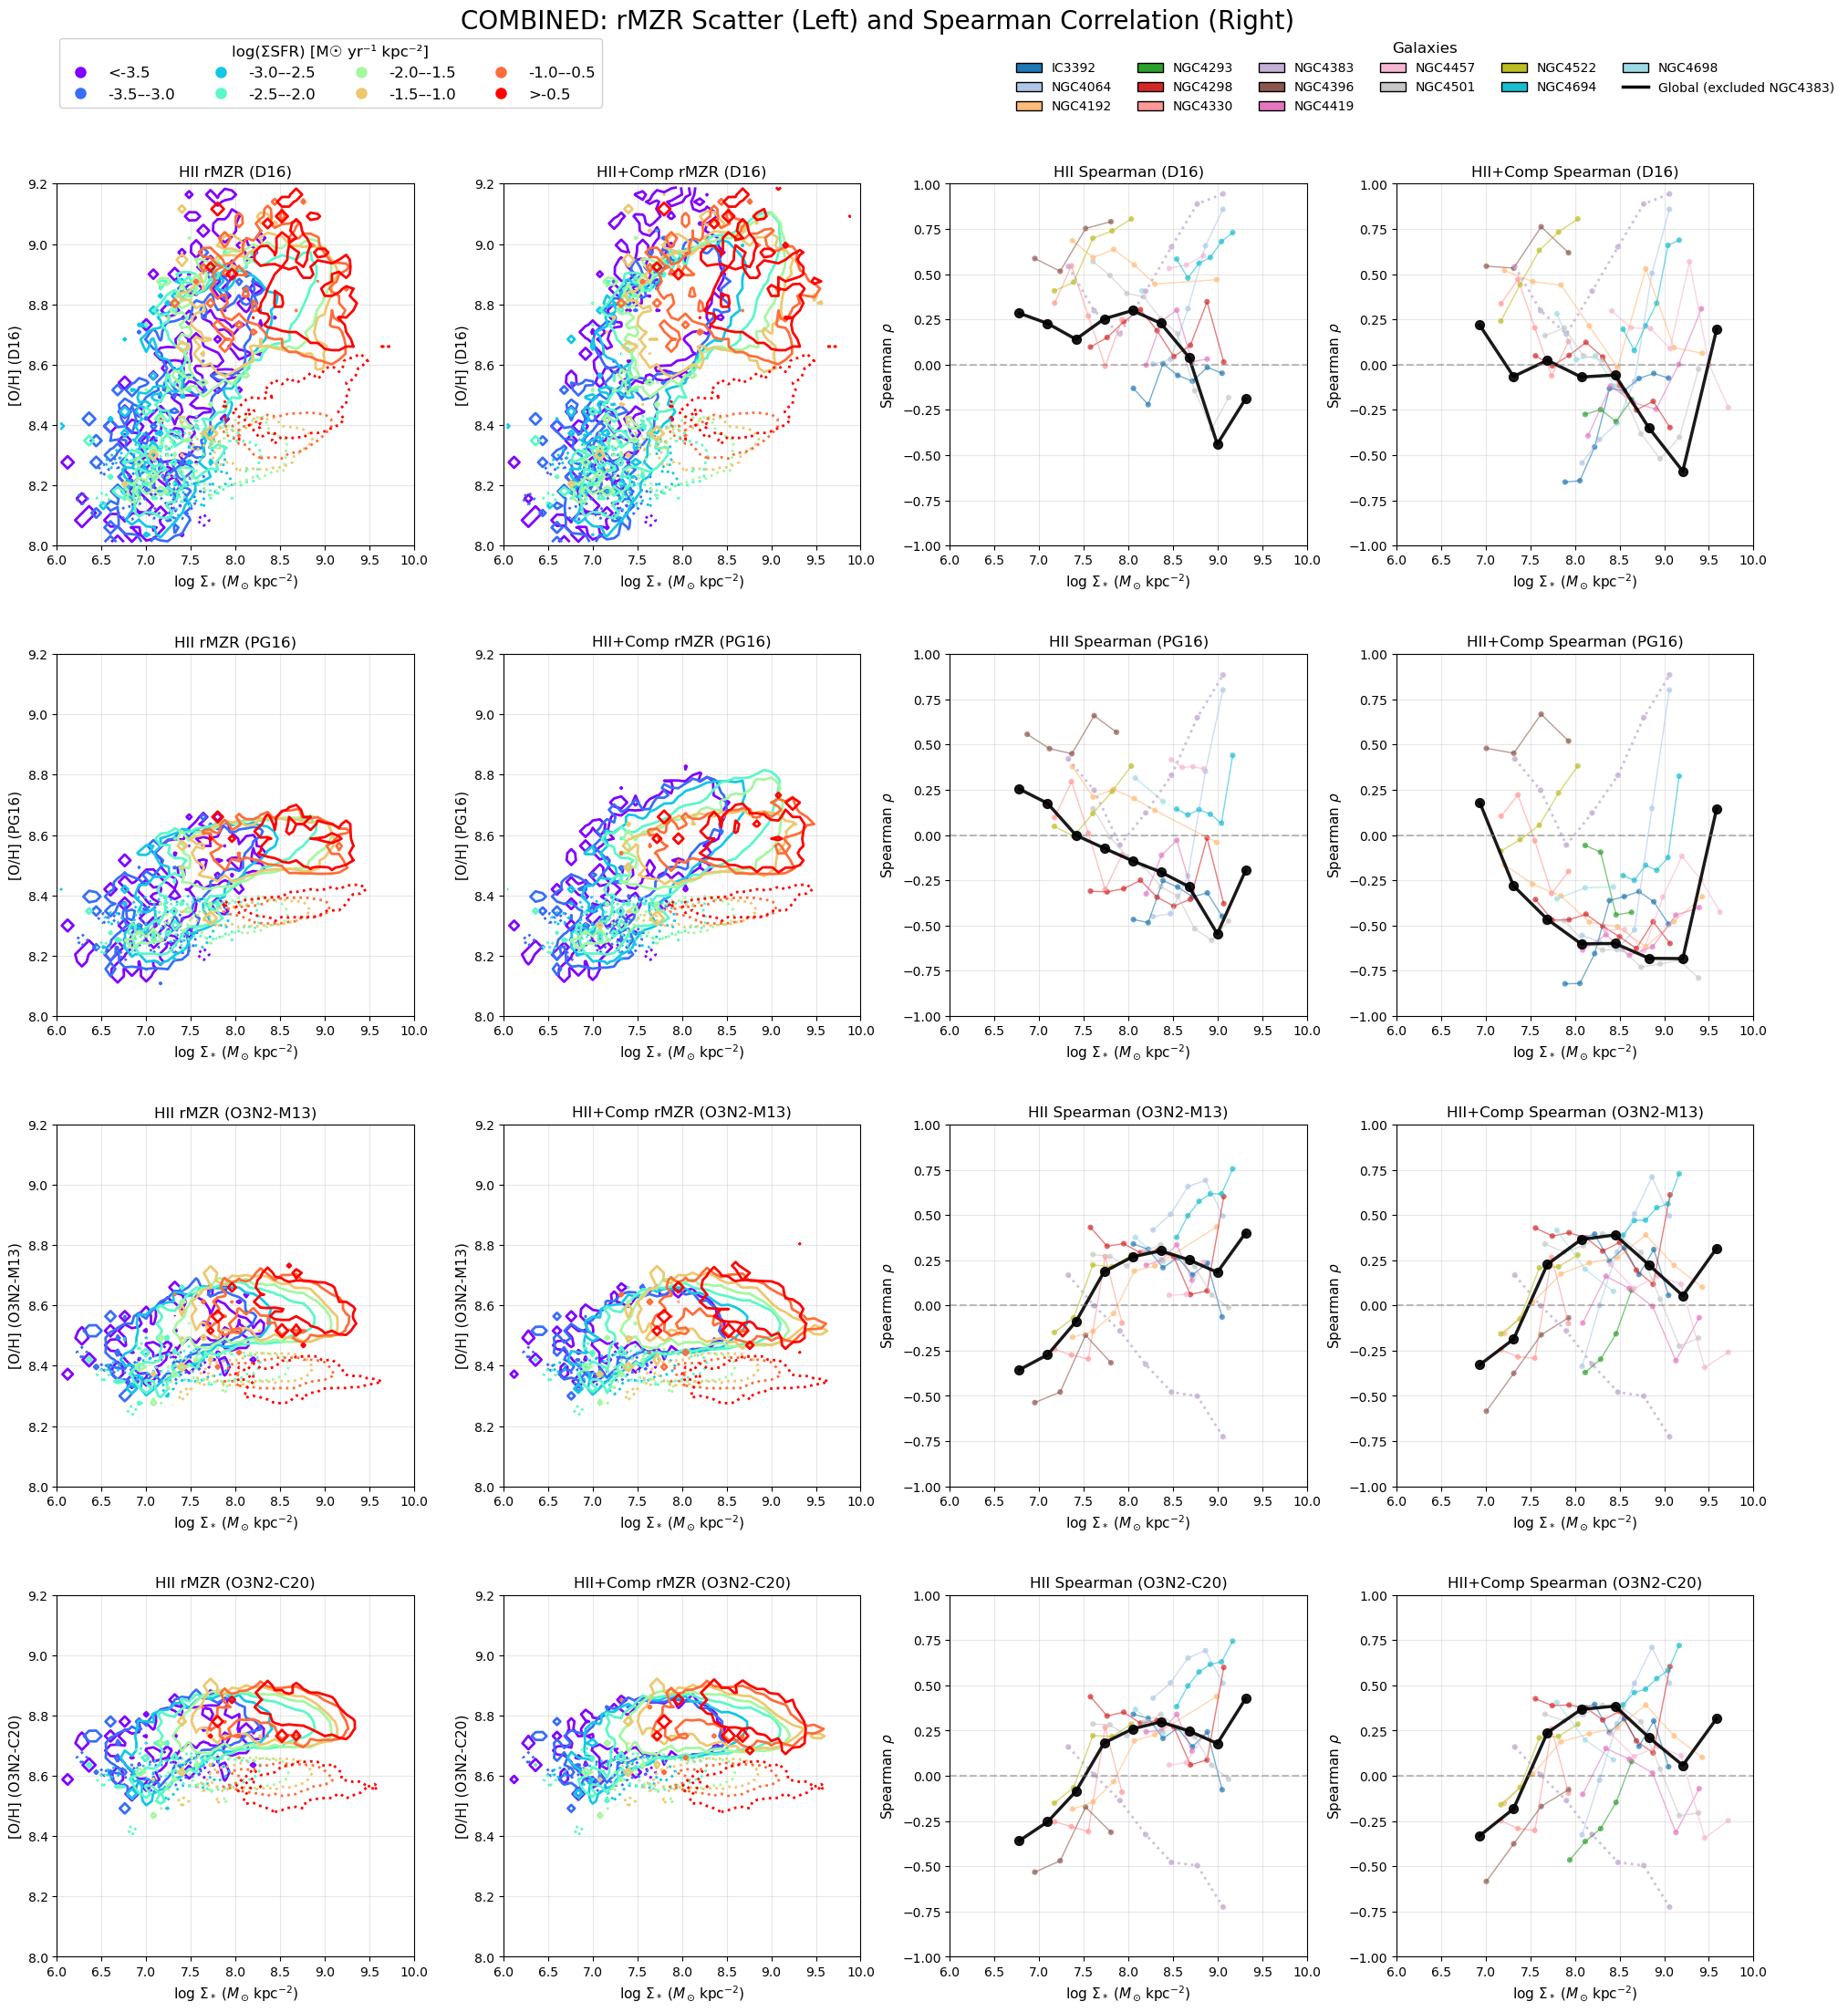

In [1]:
# ------------------------------------------------------------------
# COMBINED FIGURE: rMZR Scatter (Cols 1-2) and Spearman rho (Cols 3-4)
# WITH NGC4383 (Dotted Contours/Lines)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
from scipy.stats import spearmanr
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import matplotlib.lines as mlines

# ==========================================
# PART 1: FUNCTIONS & SETUP
# ==========================================

def load_maps_mzr(gal):
    """Load all metallicity calibrations for both HII and SF regions (MZR version)"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
        # Emission lines
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
            HB4861_FLUX_corr, HA6562_FLUX_corr, OIII5006_FLUX_corr, 
            NII6583_FLUX_corr, SII6716_FLUX_corr, SII6730_FLUX_corr)

def calculate_binned_stats_spearman(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins (Spearman version)"""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)
    
    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue
            
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            
    return (np.array(valid_centers), np.array(medians), 
            np.array(stds), np.array(counts))

def compute_spearman_track(sigM, sigSFR, oh_map, n_bins=12):
    valid_all = np.isfinite(sigM) & np.isfinite(sigSFR) & np.isfinite(oh_map)
    if np.sum(valid_all) == 0:
        return np.array([]), np.array([])

    sigM = sigM[valid_all]
    sigSFR = sigSFR[valid_all]
    oh_map = oh_map[valid_all]

    sigmaM_min = np.nanmin(sigM)
    sigmaM_max = np.nanmax(sigM)
    sigmaM_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_centers = 0.5 * (sigmaM_edges[:-1] + sigmaM_edges[1:])
    
    valid_centers = []
    rho_values = []
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM <= sigmaM_edges[i+1])
        else:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i+1])
            
        if np.sum(bin_mask) <= 20: 
            continue
            
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_map[bin_mask]
        
        sfr_off = sfr_bin - np.mean(sfr_bin)
        oh_off = oh_bin - np.mean(oh_bin)
        
        try:
            H, xedges, yedges = np.histogram2d(sfr_off, oh_off, bins=30, density=True)
            H_flat = H.flatten()
            H_sorted = np.sort(H_flat)[::-1]
            H_cumsum = np.cumsum(H_sorted)
            H_cumsum /= H_cumsum[-1]
            threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
            
            x_idx = np.searchsorted(xedges, sfr_off, side='right') - 1
            y_idx = np.searchsorted(yedges, oh_off, side='right') - 1
            x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
            y_idx = np.clip(y_idx, 0, H.shape[1] - 1)
            
            inside = H[x_idx, y_idx] >= threshold_95
        except:
            inside = np.ones_like(sfr_off, dtype=bool)
            
        x_trend = sfr_off[inside]
        y_trend = oh_off[inside]
        centers, _, _, _ = calculate_binned_stats_spearman(x_trend, y_trend, bin_width=0.2, min_unique=20)
        
        if centers.size >= 2 and np.sum(inside) > 2:
            try:
                rho, _ = spearmanr(sfr_off[inside], oh_off[inside])
                if np.isfinite(rho):
                    valid_centers.append(sigmaM_centers[i])
                    rho_values.append(rho)
            except:
                pass
                
    return np.array(valid_centers), np.array(rho_values)

# ==========================================
# PART 2: DATA COLLECTION
# ==========================================

# Get galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]
print(f"Processing {len(galaxies)} galaxies (excluding NGC4383 for stats): {', '.join(galaxies)}")

# --- MZR Data Containers (Main) ---
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

all_logSigmaM_SF = []
all_logSigmaSFR_SF = []
all_oh_d16_SF = []
all_oh_pg16_SF = []
all_oh_o3n2_m13_SF = []
all_oh_o3n2_c20_SF = []

all_logSFR_hii = [] # For binning
all_logSFR_sf = []

# --- Spearman Data Containers (Main) ---
spearman_results = {
    'HII': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']},
    'SF': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']}
}

# --- NGC4383 Data Container ---
ngc4383_data = {
    'HII': {'sigM': [], 'sigSFR': [], 'D16': [], 'PG16': [], 'O3N2-M13': [], 'O3N2-C20': []},
    'SF': {'sigM': [], 'sigSFR': [], 'D16': [], 'PG16': [], 'O3N2-M13': [], 'O3N2-C20': []}
}
ngc4383_spearman = {
    'HII': {ind: ([], []) for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']},
    'SF': {ind: ([], []) for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']}
}

print("Collecting data...")
for gal in galaxies_all:
    # Load data using the MZR loader (it has everything)
    try:
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
         logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
         HB, HA, OIII, NII, SII6716, SII6730) = load_maps_mzr(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    # --- Process MZR Data ---
    common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))
    
    common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                      np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                      np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF))
    
    if gal == 'NGC4383':
        # Store NGC4383 data separately
        ngc4383_data['HII']['sigM'] = logSigmaM[common_mask_HII].flatten()
        ngc4383_data['HII']['sigSFR'] = logSigmaSFR_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['D16'] = oh_d16_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['PG16'] = oh_pg16_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['O3N2-M13'] = oh_o3n2_m13_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['O3N2-C20'] = oh_o3n2_c20_HII[common_mask_HII].flatten()
        
        ngc4383_data['SF']['sigM'] = logSigmaM[common_mask_SF].flatten()
        ngc4383_data['SF']['sigSFR'] = logSigmaSFR_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['D16'] = oh_d16_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['PG16'] = oh_pg16_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['O3N2-M13'] = oh_o3n2_m13_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['O3N2-C20'] = oh_o3n2_c20_SF[common_mask_SF].flatten()
        
        # Compute Spearman for NGC4383
        maps_4383 = {
            'HII': {
                'D16': (logSigmaM, logSigmaSFR_HII, oh_d16_HII),
                'PG16': (logSigmaM, logSigmaSFR_HII, oh_pg16_HII),
                'O3N2-M13': (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII),
                'O3N2-C20': (logSigmaM, logSigmaSFR_HII, oh_o3n2_c20_HII)
            },
            'SF': {
                'D16': (logSigmaM, logSigmaSFR_SF, oh_d16_SF),
                'PG16': (logSigmaM, logSigmaSFR_SF, oh_pg16_SF),
                'O3N2-M13': (logSigmaM, logSigmaSFR_SF, oh_o3n2_m13_SF),
                'O3N2-C20': (logSigmaM, logSigmaSFR_SF, oh_o3n2_c20_SF)
            }
        }
        for reg in ['HII', 'SF']:
            for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
                sM, sSFR, oh = maps_4383[reg][ind]
                x, y = compute_spearman_track(sM, sSFR, oh)
                ngc4383_spearman[reg][ind] = (x, y)

    else:
        # Append Main MZR data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
        all_logSFR_hii.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        
        all_logSigmaM_SF.extend(logSigmaM[common_mask_SF].flatten())
        all_logSigmaSFR_SF.extend(logSigmaSFR_SF[common_mask_SF].flatten())
        all_oh_d16_SF.extend(oh_d16_SF[common_mask_SF].flatten())
        all_oh_pg16_SF.extend(oh_pg16_SF[common_mask_SF].flatten())
        all_oh_o3n2_m13_SF.extend(oh_o3n2_m13_SF[common_mask_SF].flatten())
        all_oh_o3n2_c20_SF.extend(oh_o3n2_c20_SF[common_mask_SF].flatten())
        all_logSFR_sf.extend(logSigmaSFR_SF[common_mask_SF].flatten())

        # --- Process Spearman Data (Main) ---
        maps = {
            'HII': {
                'D16': (logSigmaM, logSigmaSFR_HII, oh_d16_HII),
                'PG16': (logSigmaM, logSigmaSFR_HII, oh_pg16_HII),
                'O3N2-M13': (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII),
                'O3N2-C20': (logSigmaM, logSigmaSFR_HII, oh_o3n2_c20_HII)
            },
            'SF': {
                'D16': (logSigmaM, logSigmaSFR_SF, oh_d16_SF),
                'PG16': (logSigmaM, logSigmaSFR_SF, oh_pg16_SF),
                'O3N2-M13': (logSigmaM, logSigmaSFR_SF, oh_o3n2_m13_SF),
                'O3N2-C20': (logSigmaM, logSigmaSFR_SF, oh_o3n2_c20_SF)
            }
        }
        
        for reg in ['HII', 'SF']:
            for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
                sM, sSFR, oh = maps[reg][ind]
                # Compute per-galaxy track
                x, y = compute_spearman_track(sM, sSFR, oh)
                if len(x) > 0:
                    spearman_results[reg][ind]['galaxies'][gal] = (x, y)
                # Collect global pixels
                valid = np.isfinite(sM) & np.isfinite(sSFR) & np.isfinite(oh)
                if np.sum(valid) > 0:
                    spearman_results[reg][ind]['global_pixels']['sigM'].extend(sM[valid])
                    spearman_results[reg][ind]['global_pixels']['sigSFR'].extend(sSFR[valid])
                    spearman_results[reg][ind]['global_pixels']['oh'].extend(oh[valid])

# Convert MZR lists to arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)
all_logSFR_hii = np.array(all_logSFR_hii)

all_logSigmaM_SF = np.array(all_logSigmaM_SF)
all_logSigmaSFR_SF = np.array(all_logSigmaSFR_SF)
all_oh_d16_SF = np.array(all_oh_d16_SF)
all_oh_pg16_SF = np.array(all_oh_pg16_SF)
all_oh_o3n2_m13_SF = np.array(all_oh_o3n2_m13_SF)
all_oh_o3n2_c20_SF = np.array(all_oh_o3n2_c20_SF)
all_logSFR_sf = np.array(all_logSFR_sf)

# Compute global Spearman tracks (Main only)
print("Computing global Spearman trends...")
for reg in ['HII', 'SF']:
    for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
        g_data = spearman_results[reg][ind]['global_pixels']
        if len(g_data['sigM']) > 0:
            x, y = compute_spearman_track(
                np.array(g_data['sigM']), 
                np.array(g_data['sigSFR']), 
                np.array(g_data['oh'])
            )
            spearman_results[reg][ind]['global_track'] = (x, y)
        else:
            spearman_results[reg][ind]['global_track'] = (np.array([]), np.array([]))

# ==========================================
# PART 3: PLOTTING
# ==========================================

# Setup MZR bins
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
n_bins = len(sfr_bin_edges) - 1
mzr_colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']

# Setup Galaxy colors (using ALL galaxies to preserve color mapping)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Create Figure
fig = plt.figure(figsize=(24, 24))
# 4 rows, 4 columns. Top margin for legends.
gs = gridspec.GridSpec(4, 4, figure=fig, wspace=0.25, hspace=0.3, top=0.92)

calibrations = ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']
mzr_data_HII = [all_oh_d16_HII, all_oh_pg16_HII, all_oh_o3n2_m13_HII, all_oh_o3n2_c20_HII]
mzr_data_SF = [all_oh_d16_SF, all_oh_pg16_SF, all_oh_o3n2_m13_SF, all_oh_o3n2_c20_SF]

mzr_legend_handles = []
mzr_legend_labels = []

for row_idx, calib_name in enumerate(calibrations):
    # --- COL 0 & 1: MZR (Scatter) ---
    ax_mzr_HII = fig.add_subplot(gs[row_idx, 0])
    ax_mzr_SF = fig.add_subplot(gs[row_idx, 1])
    
    oh_HII = mzr_data_HII[row_idx]
    oh_SF = mzr_data_SF[row_idx]
    
    # Plot MZR HII (Contours for 13 galaxies - solid lines)
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
        if np.sum(in_bin) > 20:  # Need enough points for density estimation
            try:
                x = all_logSigmaM_HII[in_bin]
                y = oh_HII[in_bin]
                
                # Use 2D histogram directly (much faster than KDE)
                xmin, xmax = 6, 10
                ymin, ymax = 8.0, 9.2
                H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                
                # Find 95% density threshold
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                
                # Create grid centers for contour plotting
                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2
                
                # Plot solid contour at 95% threshold level for 13 galaxies
                ax_mzr_HII.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='solid', linewidths=2)
            except:
                pass
            
        if row_idx == 0 and len(mzr_legend_handles) < n_bins:
             mzr_legend_handles.append(mlines.Line2D([], [], color=mzr_colors[i], marker='o', linestyle='None', markersize=8, label=bin_labels[i]))
             mzr_legend_labels.append(bin_labels[i])
        
        # Plot NGC4383 Contours (HII) - 95% population (dotted)
        if len(ngc4383_data['HII']['sigM']) > 0:
            ngc_sigM = np.array(ngc4383_data['HII']['sigM'])
            ngc_oh = np.array(ngc4383_data['HII'][calib_name])
            ngc_sfr = np.array(ngc4383_data['HII']['sigSFR'])
            
            in_bin_ngc = (ngc_sfr >= sfr_bin_edges[i]) & (ngc_sfr < sfr_bin_edges[i+1])
            if np.sum(in_bin_ngc) > 20: # Need enough points for density estimation
                try:
                    x = ngc_sigM[in_bin_ngc]
                    y = ngc_oh[in_bin_ngc]
                    
                    # Use 2D histogram directly (much faster than KDE)
                    xmin, xmax = 6, 10
                    ymin, ymax = 8.0, 9.2
                    H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                    
                    # Find 95% density threshold
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                    
                    # Create grid centers for contour plotting
                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2
                    
                    # Plot dotted contour at 95% threshold level
                    ax_mzr_HII.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='dotted', linewidths=2)
                except:
                    pass

    # Plot MZR SF (Contours for 13 galaxies - solid lines)
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_SF >= sfr_bin_edges[i]) & (all_logSigmaSFR_SF < sfr_bin_edges[i+1])
        if np.sum(in_bin) > 20:  # Need enough points for density estimation
            try:
                x = all_logSigmaM_SF[in_bin]
                y = oh_SF[in_bin]
                
                # Create 2D histogram to find 95% density threshold
                # Use 2D histogram directly (much faster than KDE)
                xmin, xmax = 6, 10
                ymin, ymax = 8.0, 9.2
                H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                
                # Find 95% density threshold
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                
                # Create grid centers for contour plotting
                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2
                
                # Plot solid contour at 95% threshold level for 13 galaxies
                ax_mzr_SF.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='solid', linewidths=2)
            except:
                pass
        
        # Plot NGC4383 Contours (SF) - 95% population (dotted)
        if len(ngc4383_data['SF']['sigM']) > 0:
            ngc_sigM = np.array(ngc4383_data['SF']['sigM'])
            ngc_oh = np.array(ngc4383_data['SF'][calib_name])
            ngc_sfr = np.array(ngc4383_data['SF']['sigSFR'])
            
            in_bin_ngc = (ngc_sfr >= sfr_bin_edges[i]) & (ngc_sfr < sfr_bin_edges[i+1])
            if np.sum(in_bin_ngc) > 20:
                try:
                    x = ngc_sigM[in_bin_ngc]
                    y = ngc_oh[in_bin_ngc]
                    
                    # Create 2D histogram to find 95% density threshold
                    # Use 2D histogram directly (much faster than KDE)
                    xmin, xmax = 6, 10
                    ymin, ymax = 8.0, 9.2
                    H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                    
                    # Find 95% density threshold
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                    
                    # Create grid centers for contour plotting
                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2
                    
                    # Plot dotted contour at 95% threshold level
                    ax_mzr_SF.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='dotted', linewidths=2)
                except:
                    pass

    # Format MZR Axes
    for ax, region_label in zip([ax_mzr_HII, ax_mzr_SF], ['HII', 'HII+Comp']):
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
        ax.set_ylabel(f'[O/H] ({calib_name})', fontsize=11)
        ax.set_xlim(6, 10)
        ax.set_ylim(8.0, 9.2) # Fixed range for consistency
        ax.set_title(f'{region_label} rMZR ({calib_name})', fontsize=12)
        ax.grid(True, alpha=0.3)

    # --- COL 2 & 3: Spearman ---
    ax_sp_HII = fig.add_subplot(gs[row_idx, 2])
    ax_sp_SF = fig.add_subplot(gs[row_idx, 3])
    
    for ax, region_key, region_label in zip([ax_sp_HII, ax_sp_SF], ['HII', 'SF'], ['HII', 'HII+Comp']):
        # Plot individual galaxies (Main)
        for gal, (x, y) in spearman_results[region_key][calib_name]['galaxies'].items():
            color = galaxy_color_dict[gal]
            idx = np.argsort(x)
            ax.plot(x[idx], y[idx], color=color, alpha=0.6, linewidth=1)
            ax.scatter(x[idx], y[idx], color=color, s=20, alpha=0.7, edgecolors='none')
            
        # Plot NGC4383 (Dotted)
        gx_ngc, gy_ngc = ngc4383_spearman[region_key][calib_name]
        if len(gx_ngc) > 0:
            color = galaxy_color_dict['NGC4383']
            idx = np.argsort(gx_ngc)
            ax.plot(gx_ngc[idx], gy_ngc[idx], color=color, alpha=0.8, linewidth=2, linestyle=':')
            ax.scatter(gx_ngc[idx], gy_ngc[idx], color=color, s=20, alpha=0.8, edgecolors='none')

        # Plot global trend (Main only)
        gx, gy = spearman_results[region_key][calib_name].get('global_track', ([], []))
        if len(gx) > 0:
            idx = np.argsort(gx)
            ax.plot(gx[idx], gy[idx], color='black', linewidth=2.5, alpha=0.9)
            ax.scatter(gx[idx], gy[idx], color='black', s=50, alpha=0.9, zorder=10)
            
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_ylim(-1.0, 1.0)
        ax.set_xlim(6, 10)
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
        ax.set_ylabel(r'Spearman $\rho$', fontsize=11)
        ax.set_title(f'{region_label} Spearman ({calib_name})', fontsize=12)
        ax.grid(True, alpha=0.3)

# --- LEGENDS ---
# 1. MZR Legend (Left side)
fig.legend(mzr_legend_handles, mzr_legend_labels, loc='upper center', bbox_to_anchor=(0.25, 0.99),
          ncol=4, fontsize=12, framealpha=0.9, 
          title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=12)

# 2. Spearman Legend (Right side)
spearman_legend_elements = [Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal) for gal in galaxies_all]
spearman_legend_elements.append(mlines.Line2D([], [], color='black', lw=2.5, label='Global (excluded NGC4383)'))

fig.legend(handles=spearman_legend_elements, loc='upper center', bbox_to_anchor=(0.75, 0.99),
           ncol=min(len(galaxies_all)+1, 6), frameon=False, fontsize=10, title='Galaxies', title_fontsize=12)

fig.suptitle(f'COMBINED: rMZR Scatter (Left) and Spearman Correlation (Right)', fontsize=20, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
